# **Titanic: Criação de Clusters com K-Means, K-Prototypes e DBSCAN**

Grupo 1 de SI:
Ana Maria, Eduardo Mabesoone, Heitor Riquelme, Pedro Herculano, Pedro Santana

## **Importações**

In [ ]:
!pip install kmodes

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score
)
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from kmodes.kprototypes import KPrototypes

## **Carregamento do Dataset**

In [ ]:
!gdown --id 1AoYeR_iTQuM3V1eMYykZuw8LC6reuerQ
df_raw = pd.read_csv('train.csv')
display(df_raw.head(10))

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1AoYeR_iTQuM3V1eMYykZuw8LC6reuerQ
To: /content/train.csv
100% 61.2k/61.2k [00:00<00:00, 10.2MB/s]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


### Garantindo uma abordagem não-supervisionada

O rótulo `Survived` **não pode** ser usado como variável de treinamento em nenhum dos algoritmos de clusterização — isso tornaria o problema supervisionado. Guardamos esse rótulo à parte, apenas para uma **validação a posteriori** (checar se os clusters encontrados fazem sentido em relação à sobrevivência), nunca como feature de entrada.

In [ ]:
# 'Survived' é guardado à parte SOMENTE para validação a posteriori dos clusters.
# Ele NUNCA é usado como variável de treinamento em nenhum dos algoritmos abaixo.
y_survived = df_raw['Survived'].copy()

df_raw = df_raw.drop(columns='Survived')
assert 'Survived' not in df_raw.columns, 'Survived não pode estar entre as features de treinamento!'

print('Coluna "Survived" removida do dataset de treinamento (abordagem não-supervisionada confirmada).')
print(f'Colunas restantes ({df_raw.shape[1]}): {df_raw.columns.tolist()}')

Coluna "Survived" removida do dataset de treinamento (abordagem não-supervisionada confirmada).
Colunas restantes (11): ['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


### Funções auxiliares de métricas e visualização

In [ ]:
def calcular_metricas_k(X_num, k_range=range(2, 11)):
    """Calcula Elbow (inércia), Silhouette, Calinski-Harabasz e Davies-Bouldin para K-Means."""
    resultados = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_num)
        resultados.append({
            'k'                 : k,
            'Inércia (Elbow)'   : km.inertia_,
            'Silhouette'        : silhouette_score(X_num, labels),
            'Calinski-Harabasz' : calinski_harabasz_score(X_num, labels),
            'Davies-Bouldin'    : davies_bouldin_score(X_num, labels),
        })
    return pd.DataFrame(resultados).set_index('k')


def bic_kmeans(X, k_range=range(2, 11)):
    """Calcula uma aproximação de BIC para K-Means."""
    bics = []
    n, d = X.shape
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
        labels = km.labels_
        # Variância pooled
        var = km.inertia_ / (n - k) if (n - k) > 0 else 1e-10
        # log-likelihood gaussiana
        ll = -0.5 * n * np.log(2 * np.pi * var) - km.inertia_ / (2 * var)
        # número de parâmetros livres
        p = k * d + k - 1
        bics.append(ll - 0.5 * p * np.log(n))
    return pd.Series(bics, index=list(k_range), name='BIC')


def plotar_metricas(df_met, bic_series, titulo_prefix=''):
    """Plota os 5 gráficos de métricas para escolha de k."""
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()

    # Elbow
    axes[0].plot(df_met.index, df_met['Inércia (Elbow)'], marker='o', color='steelblue')
    axes[0].set_title(f'{titulo_prefix}Elbow (Inércia)')
    axes[0].set_xlabel('k')

    # Silhouette — maior é melhor
    axes[1].plot(df_met.index, df_met['Silhouette'], marker='o', color='coral')
    axes[1].set_title(f'{titulo_prefix}Silhouette (↑ melhor)')
    axes[1].set_xlabel('k')

    # Calinski-Harabasz — maior é melhor
    axes[2].plot(df_met.index, df_met['Calinski-Harabasz'], marker='o', color='seagreen')
    axes[2].set_title(f'{titulo_prefix}Calinski-Harabasz (↑ melhor)')
    axes[2].set_xlabel('k')

    # Davies-Bouldin — menor é melhor
    axes[3].plot(df_met.index, df_met['Davies-Bouldin'], marker='o', color='purple')
    axes[3].set_title(f'{titulo_prefix}Davies-Bouldin (↓ melhor)')
    axes[3].set_xlabel('k')

    # BIC — maior é melhor
    axes[4].plot(bic_series.index, bic_series.values, marker='o', color='darkorange')
    axes[4].set_title(f'{titulo_prefix}BIC (↑ melhor)')
    axes[4].set_xlabel('k')

    axes[5].axis('off')
    plt.tight_layout()
    plt.show()


def resumo_votos(df_met, bic_series):
    """Indica o k vencedor em cada métrica e o k mais votado.

    IMPORTANTE: em problemas não-supervisionados não existe uma métrica
    conclusiva única — cada métrica captura uma noção diferente de
    'boa formação de cluster'. A votação por maioria é apenas um critério
    prático de desempate, não uma prova de que o k escolhido é 'correto'.
    """
    votos = {
        'Elbow'             : df_met['Inércia (Elbow)'].diff().diff().abs().idxmax(),
        'Silhouette'        : df_met['Silhouette'].idxmax(),
        'Calinski-Harabasz' : df_met['Calinski-Harabasz'].idxmax(),
        'Davies-Bouldin'    : df_met['Davies-Bouldin'].idxmin(),
        'BIC'               : bic_series.idxmax(),
    }
    print('Melhor k por métrica:')
    for met, k in votos.items():
        print(f'  {met:22s}: k = {k}')
    from collections import Counter
    contagem = Counter(votos.values())
    mais_votado, n_votos = contagem.most_common(1)[0]
    total = len(votos)
    print(f'\n→ k mais votado pela maioria: {mais_votado} ({n_votos}/{total} métricas concordam)')
    if n_votos < total:
        divergentes = {m: k for m, k in votos.items() if k != mais_votado}
        print(f'   Atenção: as métricas não são unânimes. Divergências: {divergentes}')
        print('   Isso é esperado em clustering — vale inspecionar os gráficos antes de decidir.')
    return mais_votado


def distancias_intra_inter(X, labels):
    """Calcula distância média intra-cluster e inter-cluster (centróides)."""
    clusters = np.unique(labels[labels >= 0])
    centroides = np.array([X[labels == c].mean(axis=0) for c in clusters])

    # Intra-cluster: distância média de cada ponto ao seu centróide
    intra = np.mean([
        np.linalg.norm(X[labels == c] - centroides[i], axis=1).mean()
        for i, c in enumerate(clusters)
    ])

    # Inter-cluster: distância média entre todos os pares de centróides
    n_c = len(centroides)
    dists = [
        np.linalg.norm(centroides[i] - centroides[j])
        for i in range(n_c) for j in range(i + 1, n_c)
    ]
    inter = np.mean(dists) if dists else 0.0

    print(f'  Distância Intra-cluster (média): {intra:.4f}')
    print(f'  Distância Inter-cluster (média entre centróides): {inter:.4f}')
    return intra, inter


def arvore_de_rotulacao(X, labels, feature_names, titulo=''):
    """Treina uma DT para classificar os clusters e extrai as regras."""
    mask = labels >= 0  # exclui ruído do DBSCAN (-1)
    dt = DecisionTreeClassifier(max_depth=4, random_state=42)
    dt.fit(X[mask], labels[mask])

    print(f'\n=== Regras da Árvore — {titulo} ===')
    print(export_text(dt, feature_names=list(feature_names)))

    fig, ax = plt.subplots(figsize=(22, 9))
    cluster_names = [f'Cluster {i}' for i in sorted(np.unique(labels[mask]))]
    plot_tree(
        dt, feature_names=list(feature_names),
        class_names=cluster_names,
        filled=True, rounded=True, max_depth=4, ax=ax, fontsize=7
    )
    plt.title(f'Árvore de Rotulação — {titulo} (max_depth=4)', fontsize=13)
    plt.tight_layout()
    plt.show()
    return dt


def perfil_cluster(df, cluster_col, num_cols=None, cat_cols=None, top_n=3):
    """Resume as características mais distintivas de cada cluster.

    Para colunas numéricas: mostra as `top_n` variáveis cujo valor médio no
    cluster mais se afasta (em desvios-padrão) da média geral — um jeito
    automático de responder 'quais as características principais do cluster?'.
    Para colunas categóricas: mostra a categoria mais frequente e sua proporção.
    """
    df_ = df.copy()
    clusters = sorted(df_[cluster_col].unique())

    if num_cols is None:
        num_cols = df_.select_dtypes(include=[np.number]).columns.tolist()
        num_cols = [c for c in num_cols if c != cluster_col]

    medias_globais = df_[num_cols].mean()
    desvios_globais = df_[num_cols].std().replace(0, 1e-9)

    for c in clusters:
        sub = df_[df_[cluster_col] == c]
        pct = len(sub) / len(df_) * 100
        print(f'\n--- Cluster {c} ({len(sub)} pontos, {pct:.1f}% da base) ---')

        if num_cols:
            z = ((sub[num_cols].mean() - medias_globais) / desvios_globais).abs().sort_values(ascending=False)
            print(f'  Variáveis numéricas mais distintivas (|z-score| da média geral):')
            for col in z.index[:top_n]:
                print(f'    {col:15s}: média no cluster = {sub[col].mean():.2f}'
                      f' | média geral = {medias_globais[col]:.2f} | z = {z[col]:.2f}')

        if cat_cols:
            print(f'  Categorias predominantes:')
            for col in cat_cols:
                if col not in sub.columns:
                    continue
                moda = sub[col].value_counts(normalize=True)
                if len(moda) == 0:
                    continue
                top_cat, top_prop = moda.index[0], moda.iloc[0]
                print(f'    {col:15s}: {top_cat} ({top_prop:.1%} do cluster)')


def validar_com_survived(labels, y_survived, titulo=''):
    """Valida os clusters a posteriori cruzando com a taxa de sobrevivência real.

    ATENÇÃO: isto é apenas uma checagem de sanidade / extração de conhecimento
    sobre os grupos formados — 'Survived' nunca foi usado para treinar os
    algoritmos de clusterização.
    """
    df_val = pd.DataFrame({'Cluster': labels, 'Survived': y_survived.values})
    tab = pd.crosstab(df_val['Cluster'], df_val['Survived'], margins=True, margins_name='Total')
    taxa = df_val.groupby('Cluster')['Survived'].mean().rename('Taxa de Sobrevivência')

    print(f'=== Validação a posteriori com Survived — {titulo} ===')
    display(tab)
    print('\nTaxa de sobrevivência por cluster:')
    display(taxa.round(3).to_frame())
    return tab, taxa


def comparar_algoritmos(labels_dict):
    """Compara pares de rotulagens de algoritmos diferentes via ARI e NMI.

    ARI (Adjusted Rand Index) e NMI (Normalized Mutual Information) medem o
    quanto duas partições concordam sobre o agrupamento dos mesmos pontos,
    independente dos nomes/índices dos clusters. Valores próximos de 1 =
    forte concordância; próximos de 0 = concordância ao nível do acaso.
    """
    nomes = list(labels_dict.keys())
    ari_matrix = pd.DataFrame(index=nomes, columns=nomes, dtype=float)
    nmi_matrix = pd.DataFrame(index=nomes, columns=nomes, dtype=float)

    for a in nomes:
        for b in nomes:
            la, lb = labels_dict[a], labels_dict[b]
            ari_matrix.loc[a, b] = adjusted_rand_score(la, lb)
            nmi_matrix.loc[a, b] = normalized_mutual_info_score(la, lb)

    print('Adjusted Rand Index (ARI) entre algoritmos:')
    display(ari_matrix.round(3))
    print('\nNormalized Mutual Information (NMI) entre algoritmos:')
    display(nmi_matrix.round(3))
    return ari_matrix, nmi_matrix

---
# **PARTE 1 — Sem tratamento de dados**

Pré-processamento mínimo:
- Remove `PassengerId`, `Ticket`, `Name`, `Cabin` (texto livre sem padrão aproveitável).
- `Age` e `Fare` nulos → imputação com mediana.
- `Embarked` nulo → imputação com moda.
- `Sex` e `Embarked` → `LabelEncoder` (para K-Prototypes) e **one-hot** (para K-Means / DBSCAN).
- Normalização MinMax das colunas numéricas (obrigatório para algoritmos baseados em distância).

In [ ]:
DROP_COLS = ['PassengerId', 'Ticket', 'Name', 'Cabin']
CAT_COLS  = ['Sex', 'Embarked']
NUM_COLS  = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']

def prep_minimo(df_input):
    df = df_input.copy()
    df = df.drop(columns=DROP_COLS, errors='ignore')

    # Imputação simples
    df['Age']      = df['Age'].fillna(df['Age'].median())
    df['Fare']     = df['Fare'].fillna(df['Fare'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    return df

df_s = prep_minimo(df_raw)
print(f'Shape após remoção e imputação: {df_s.shape}')
display(df_s.head())

Shape após remoção e imputação: (891, 7)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [ ]:
# ---- Versão para K-Means / DBSCAN: one-hot + normalização ----
df_s_onehot = pd.get_dummies(df_s, columns=CAT_COLS)

scaler_s = MinMaxScaler()
X_s = scaler_s.fit_transform(df_s_onehot).astype(float)
feature_names_s = df_s_onehot.columns.tolist()

print(f'Shape para K-Means/DBSCAN: {X_s.shape}')
print(f'Features: {feature_names_s}')

Shape para K-Means/DBSCAN: (891, 10)
Features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


In [ ]:
# ---- Versão para K-Prototypes: numéricas normalizadas + categóricas originais ----
num_cols_s = [c for c in df_s.columns if c not in CAT_COLS]
cat_cols_s = CAT_COLS

df_s_kp = df_s.copy()
df_s_kp[num_cols_s] = scaler_s.fit_transform(
    MinMaxScaler().fit_transform(df_s_kp[num_cols_s])
)

# Índices das colunas categóricas (K-Prototypes exige índices)
cat_idx_s = [df_s_kp.columns.tolist().index(c) for c in cat_cols_s]
X_s_kp = df_s_kp.values
print(f'Shape para K-Prototypes: {X_s_kp.shape} | cat_idx: {cat_idx_s}')

Shape para K-Prototypes: (891, 7) | cat_idx: [1, 6]


## 1.2 K-Means — sem tratamento

### 1.2.1 Escolha de k pelas métricas

,Inércia (Elbow),Silhouette,Calinski-Harabasz,Davies-Bouldin
k,,,,
2,596.8219,0.4563,617.9622,1.0747
3,427.0217,0.5045,607.9094,0.9509
4,320.6491,0.5543,637.1960,1.0810
5,238.7154,0.6062,717.2255,0.7537
6,181.9820,0.5675,806.9888,0.7359
7,143.5698,0.6011,890.8719,0.6329
8,116.7168,0.5751,967.2457,0.6914
9,96.3572,0.5852,1047.3005,0.6200
10,81.0374,0.5916,1124.1735,0.5939


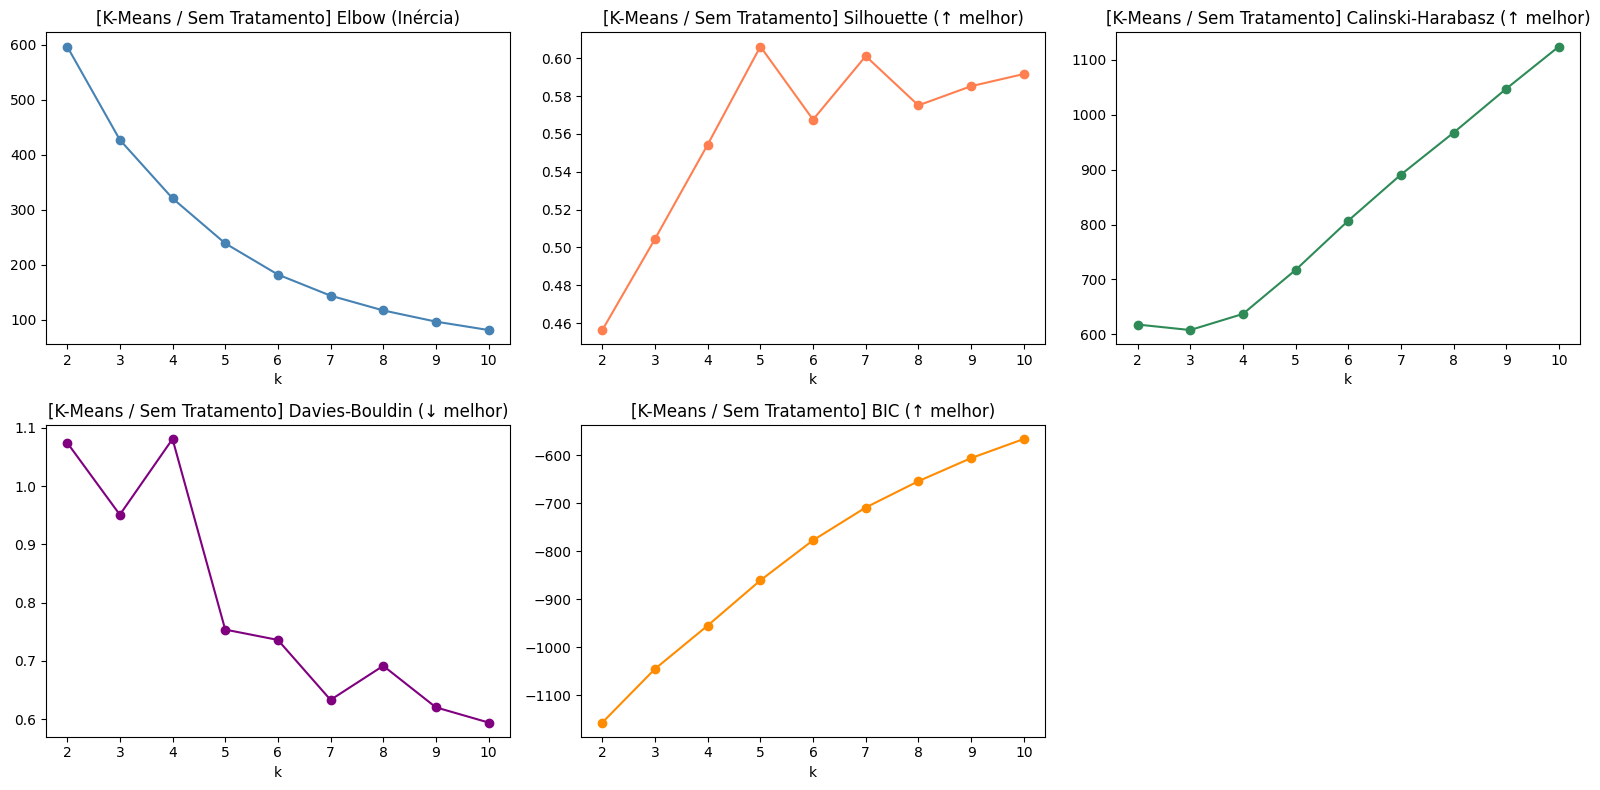

In [ ]:
df_met_km_s = calcular_metricas_k(X_s, k_range=range(2, 11))
bic_km_s    = bic_kmeans(X_s, k_range=range(2, 11))
display(df_met_km_s.round(4))
plotar_metricas(df_met_km_s, bic_km_s, titulo_prefix='[K-Means / Sem Tratamento] ')

In [ ]:
K_KM_S = resumo_votos(df_met_km_s, bic_km_s)

Melhor k por métrica:
  Elbow                 : k = 4
  Silhouette            : k = 5
  Calinski-Harabasz     : k = 10
  Davies-Bouldin        : k = 10
  BIC                   : k = 10

→ k mais votado pela maioria: 10 (3/5 métricas concordam)
   Atenção: as métricas não são unânimes. Divergências: {'Elbow': np.int64(4), 'Silhouette': np.int64(5)}
   Isso é esperado em clustering — vale inspecionar os gráficos antes de decidir.


### 1.2.2 Treinamento com o k escolhido

In [ ]:
km_s = KMeans(n_clusters=K_KM_S, random_state=42, n_init=10)
labels_km_s = km_s.fit_predict(X_s)

print(f'K-Means [Sem Tratamento] — k={K_KM_S}')
print('Distribuição dos clusters:')
print(pd.Series(labels_km_s).value_counts().sort_index())

print('\nMétricas do modelo final:')
print(f'  Silhouette        : {silhouette_score(X_s, labels_km_s):.4f}')
print(f'  Calinski-Harabasz : {calinski_harabasz_score(X_s, labels_km_s):.4f}')
print(f'  Davies-Bouldin    : {davies_bouldin_score(X_s, labels_km_s):.4f}')

print('\nDistâncias:')
intra_km_s, inter_km_s = distancias_intra_inter(X_s, labels_km_s)

K-Means [Sem Tratamento] — k=10
Distribuição dos clusters:
0    265
1     88
2     43
3     36
4    117
5     42
6    176
7     41
8     30
9     53
Name: count, dtype: int64

Métricas do modelo final:
  Silhouette        : 0.5916
  Calinski-Harabasz : 1124.1735
  Davies-Bouldin    : 0.5939

Distâncias:
  Distância Intra-cluster (média): 0.2505
  Distância Inter-cluster (média entre centróides): 1.6681


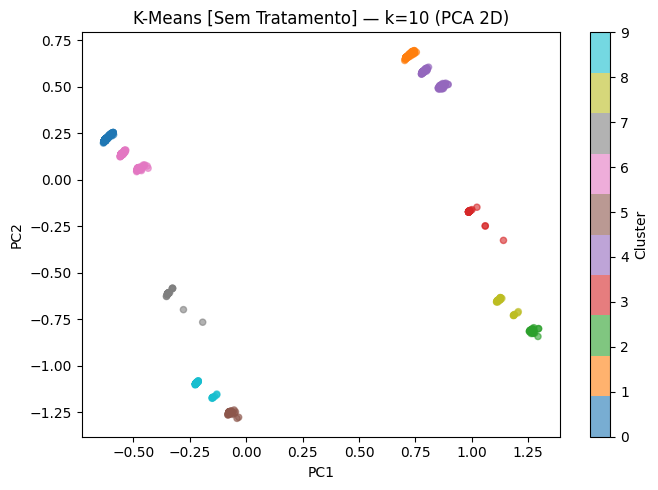

In [ ]:
# Visualização 2D (PCA para redução)
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_s_2d = pca.fit_transform(X_s)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_s_2d[:, 0], X_s_2d[:, 1], c=labels_km_s, cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-Means [Sem Tratamento] — k={K_KM_S} (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

### 1.2.3 Árvore de rotulação e extração de regras


=== Regras da Árvore — K-Means / Sem Tratamento ===
|--- Pclass <= 0.75
|   |--- Sex_female <= 0.50
|   |   |--- Embarked_S <= 0.50
|   |   |   |--- Pclass <= 0.25
|   |   |   |   |--- class: 5
|   |   |   |--- Pclass >  0.25
|   |   |   |   |--- class: 9
|   |   |--- Embarked_S >  0.50
|   |   |   |--- class: 6
|   |--- Sex_female >  0.50
|   |   |--- Embarked_S <= 0.50
|   |   |   |--- Pclass <= 0.25
|   |   |   |   |--- class: 2
|   |   |   |--- Pclass >  0.25
|   |   |   |   |--- class: 8
|   |   |--- Embarked_S >  0.50
|   |   |   |--- class: 4
|--- Pclass >  0.75
|   |--- Sex_male <= 0.50
|   |   |--- Embarked_S <= 0.50
|   |   |   |--- Embarked_Q <= 0.50
|   |   |   |   |--- class: 8
|   |   |   |--- Embarked_Q >  0.50
|   |   |   |   |--- class: 3
|   |   |--- Embarked_S >  0.50
|   |   |   |--- class: 1
|   |--- Sex_male >  0.50
|   |   |--- Embarked_S <= 0.50
|   |   |   |--- Embarked_C <= 0.50
|   |   |   |   |--- class: 7
|   |   |   |--- Embarked_C >  0.50
|   |   |   |  

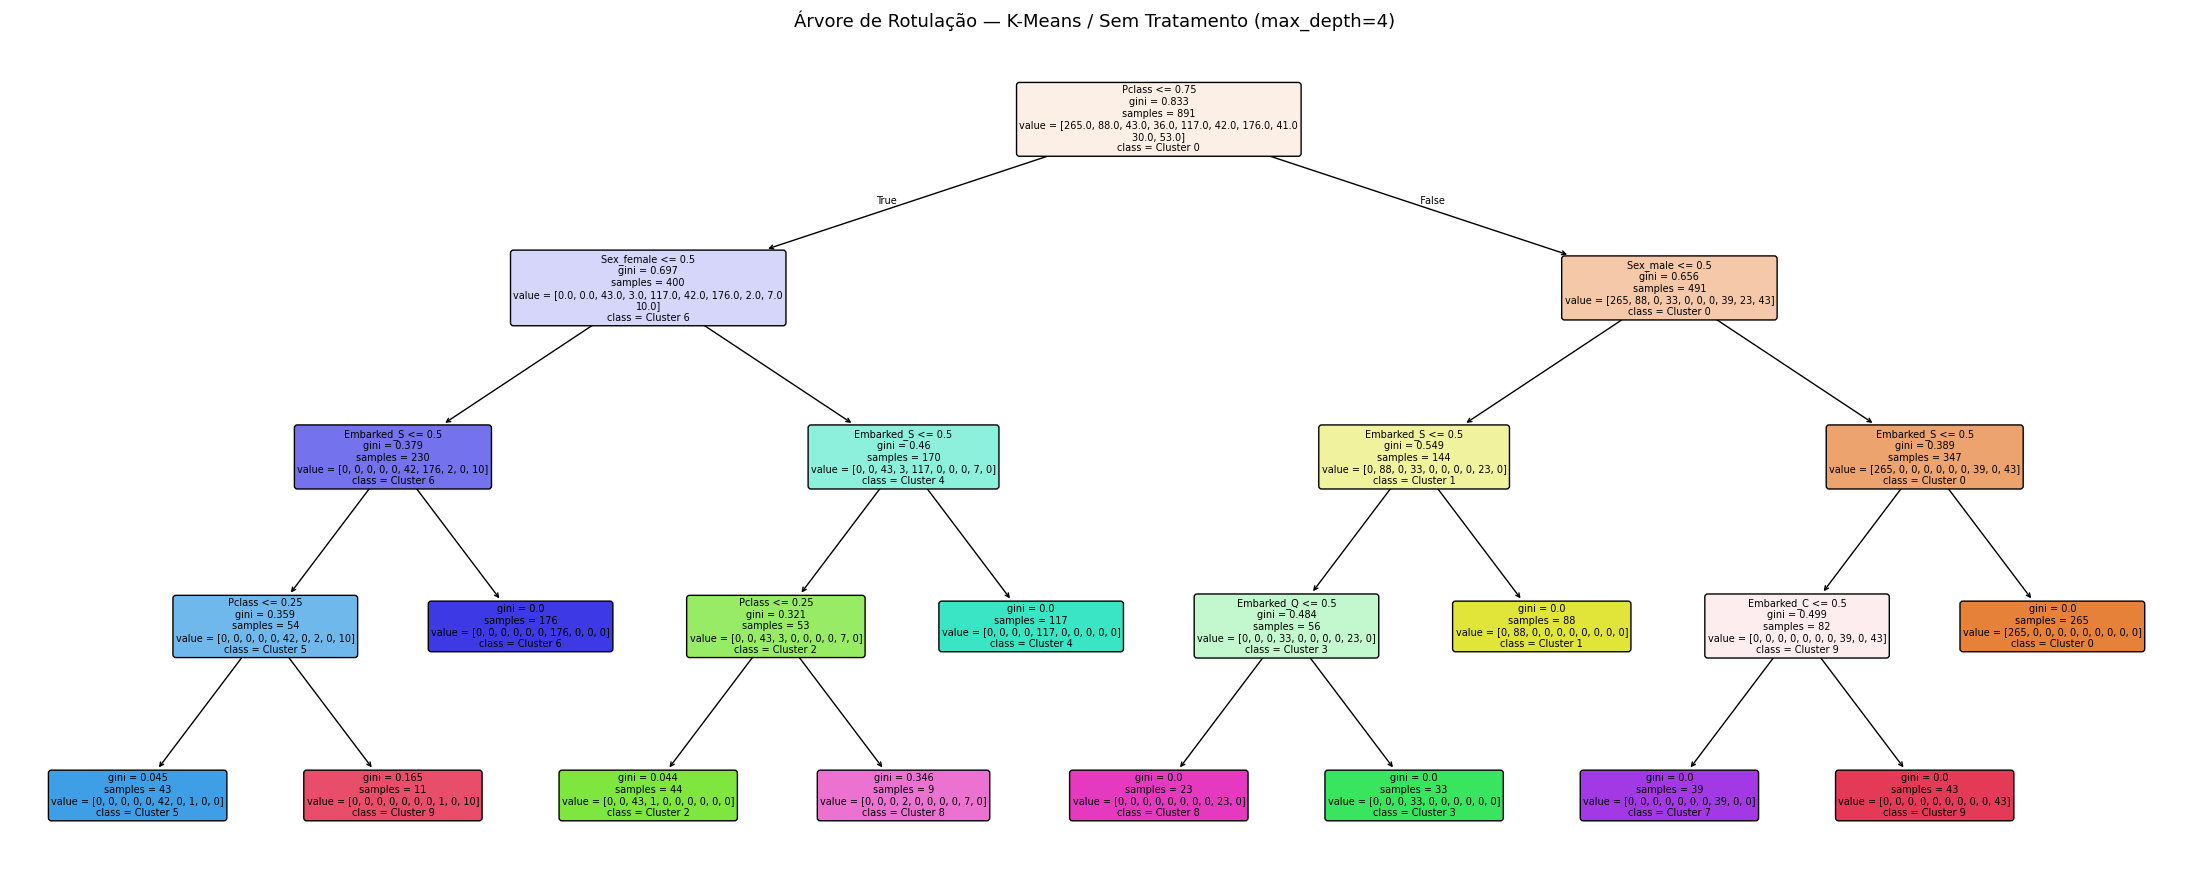

In [ ]:
dt_km_s = arvore_de_rotulacao(X_s, labels_km_s, feature_names_s, titulo='K-Means / Sem Tratamento')

### 1.2.4 Análise dos clusters

Perfil médio por cluster (K-Means / Sem Tratamento):


,Pclass,Age,SibSp,Parch,Fare
Cluster_KM,,,,,
0,3.00,26.85,0.53,0.25,13.31
1,3.00,23.88,1.24,1.00,18.67
2,1.00,35.12,0.51,0.30,115.64
3,2.89,26.76,0.22,0.22,12.63
4,1.57,31.12,0.52,0.62,54.54
5,1.00,38.38,0.24,0.33,93.54
6,1.55,34.52,0.33,0.22,34.37
7,2.93,29.15,0.61,0.12,13.84
8,2.77,18.50,0.60,0.77,17.16


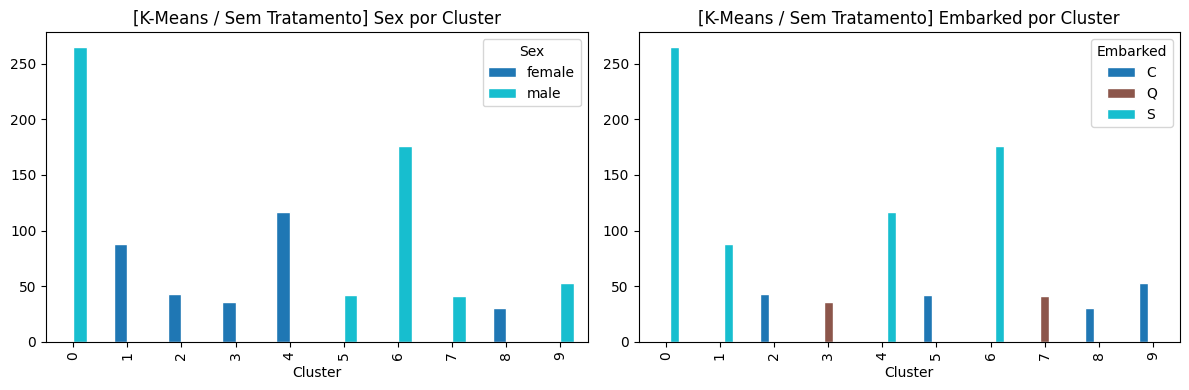

In [ ]:
df_s_analise = df_s.copy()
df_s_analise['Cluster_KM'] = labels_km_s

print('Perfil médio por cluster (K-Means / Sem Tratamento):')
display(df_s_analise.groupby('Cluster_KM').mean(numeric_only=True).round(2))

# Distribuição de Sex por cluster
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_s_analise.groupby(['Cluster_KM', 'Sex']).size().unstack(fill_value=0).plot(
    kind='bar', ax=axes[0], colormap='tab10', edgecolor='white'
)
axes[0].set_title('[K-Means / Sem Tratamento] Sex por Cluster')
axes[0].set_xlabel('Cluster')

df_s_analise.groupby(['Cluster_KM', 'Embarked']).size().unstack(fill_value=0).plot(
    kind='bar', ax=axes[1], colormap='tab10', edgecolor='white'
)
axes[1].set_title('[K-Means / Sem Tratamento] Embarked por Cluster')
axes[1].set_xlabel('Cluster')
plt.tight_layout()
plt.show()


--- Cluster 0 (265 pontos, 29.7% da base) ---
  Variáveis numéricas mais distintivas (|z-score| da média geral):
    Pclass         : média no cluster = 3.00 | média geral = 2.31 | z = 0.83
    Fare           : média no cluster = 13.31 | média geral = 32.20 | z = 0.38
    Age            : média no cluster = 26.85 | média geral = 29.36 | z = 0.19
  Categorias predominantes:
    Sex            : male (100.0% do cluster)
    Embarked       : S (100.0% do cluster)

--- Cluster 1 (88 pontos, 9.9% da base) ---
  Variáveis numéricas mais distintivas (|z-score| da média geral):
    Pclass         : média no cluster = 3.00 | média geral = 2.31 | z = 0.83
    Parch          : média no cluster = 1.00 | média geral = 0.38 | z = 0.77
    SibSp          : média no cluster = 1.24 | média geral = 0.52 | z = 0.65
  Categorias predominantes:
    Sex            : female (100.0% do cluster)
    Embarked       : S (100.0% do cluster)

--- Cluster 2 (43 pontos, 4.8% da base) ---
  Variáveis numéricas mais 

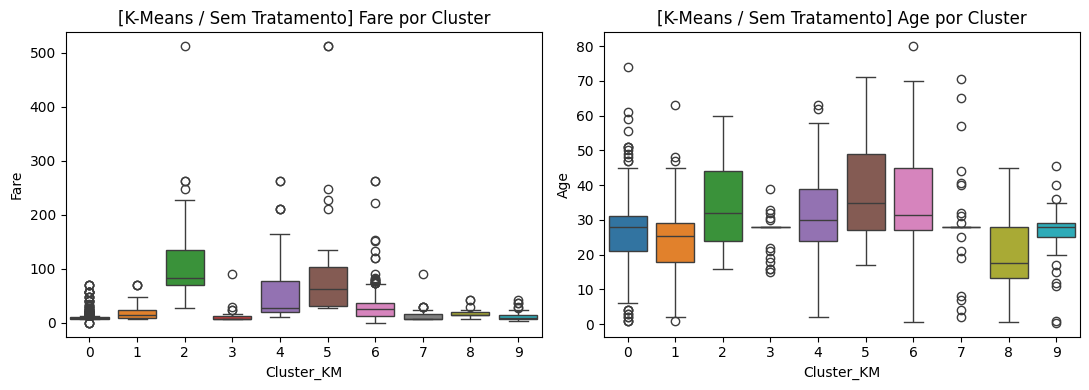

=== Validação a posteriori com Survived — K-Means / Sem Tratamento ===


Survived,0,1,Total
Cluster,,,
0,231,34,265
1,55,33,88
2,1,42,43
3,9,27,36
4,8,109,117
5,25,17,42
6,133,43,176
7,38,3,41
8,8,22,30



Taxa de sobrevivência por cluster:


,Taxa de Sobrevivência
Cluster,
0,0.128
1,0.375
2,0.977
3,0.750
4,0.932
5,0.405
6,0.244
7,0.073
8,0.733


(Survived    0    1  Total
 Cluster                  
 0         231   34    265
 1          55   33     88
 2           1   42     43
 3           9   27     36
 4           8  109    117
 5          25   17     42
 6         133   43    176
 7          38    3     41
 8           8   22     30
 9          41   12     53
 Total     549  342    891,
 Cluster
 0    0.128302
 1    0.375000
 2    0.976744
 3    0.750000
 4    0.931624
 5    0.404762
 6    0.244318
 7    0.073171
 8    0.733333
 9    0.226415
 Name: Taxa de Sobrevivência, dtype: float64)

In [ ]:
perfil_cluster(
    df_s_analise, 'Cluster_KM',
    num_cols=['Age', 'Fare', 'SibSp', 'Parch', 'Pclass'],
    cat_cols=['Sex', 'Embarked']
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df_s_analise, x='Cluster_KM', y='Fare', ax=axes[0], palette='tab10')
axes[0].set_title('[K-Means / Sem Tratamento] Fare por Cluster')
sns.boxplot(data=df_s_analise, x='Cluster_KM', y='Age', ax=axes[1], palette='tab10')
axes[1].set_title('[K-Means / Sem Tratamento] Age por Cluster')
plt.tight_layout()
plt.show()

validar_com_survived(labels_km_s, y_survived, titulo='K-Means / Sem Tratamento')

## 1.3 K-Prototypes — sem tratamento

### 1.3.1 Escolha de k

> **Nota sobre o BIC**: assim como na Parte 3, o BIC aproximado (`bic_kmeans`) não se aplica diretamente ao K-Prototypes por assumir distância gaussiana pura. Usamos o **Custo** no lugar do BIC, junto com Silhouette, Calinski-Harabasz e Davies-Bouldin.

In [ ]:
# K-Prototypes usa custo (equivalente à inércia do K-Means)
# Silhouette exige matriz numérica; usamos a parte numérica para o cálculo
X_s_kp_num = X_s_kp[:, [i for i in range(X_s_kp.shape[1]) if i not in cat_idx_s]].astype(float)

k_range = range(2, 11)
resultados_kp_s = []

for k in k_range:
    kp = KPrototypes(n_clusters=k, init='Cao', random_state=42, n_init=3, verbose=0)
    labels_kp = kp.fit_predict(X_s_kp, categorical=cat_idx_s)
    sil  = silhouette_score(X_s_kp_num, labels_kp) if len(np.unique(labels_kp)) > 1 else -1
    ch   = calinski_harabasz_score(X_s_kp_num, labels_kp) if len(np.unique(labels_kp)) > 1 else 0
    db   = davies_bouldin_score(X_s_kp_num, labels_kp) if len(np.unique(labels_kp)) > 1 else 99
    resultados_kp_s.append({
        'k': k, 'Custo (Elbow)': kp.cost_, 'Silhouette': sil,
        'Calinski-Harabasz': ch, 'Davies-Bouldin': db
    })
    print(f'k={k} | Custo: {kp.cost_:.2f} | Silhouette: {sil:.4f} | CH: {ch:.2f} | DB: {db:.4f}')

df_met_kp_s = pd.DataFrame(resultados_kp_s).set_index('k')
display(df_met_kp_s.round(4))

k=2 | Custo: 139.52 | Silhouette: 0.5656 | CH: 1381.89 | DB: 0.7011
k=3 | Custo: 112.37 | Silhouette: 0.5328 | CH: 1209.80 | DB: 0.8036
k=4 | Custo: 95.57 | Silhouette: 0.5465 | CH: 1126.95 | DB: 0.9513
k=5 | Custo: 85.14 | Silhouette: 0.4755 | CH: 914.30 | DB: 1.3990
k=6 | Custo: 77.52 | Silhouette: 0.2300 | CH: 768.48 | DB: 1.9452
k=7 | Custo: 70.65 | Silhouette: 0.1172 | CH: 647.60 | DB: 2.2980
k=8 | Custo: 66.08 | Silhouette: 0.0552 | CH: 596.58 | DB: 2.9187
k=9 | Custo: 64.02 | Silhouette: 0.0619 | CH: 571.36 | DB: 2.4739
k=10 | Custo: 62.29 | Silhouette: 0.0767 | CH: 541.62 | DB: 2.9673


,Custo (Elbow),Silhouette,Calinski-Harabasz,Davies-Bouldin
k,,,,
2,139.5200,0.5656,1381.8856,0.7011
3,112.3730,0.5328,1209.7978,0.8036
4,95.5687,0.5465,1126.9495,0.9513
5,85.1379,0.4755,914.2990,1.3990
6,77.5222,0.2300,768.4844,1.9452
7,70.6486,0.1172,647.5994,2.2980
8,66.0789,0.0552,596.5797,2.9187
9,64.0169,0.0619,571.3553,2.4739
10,62.2907,0.0767,541.6235,2.9673


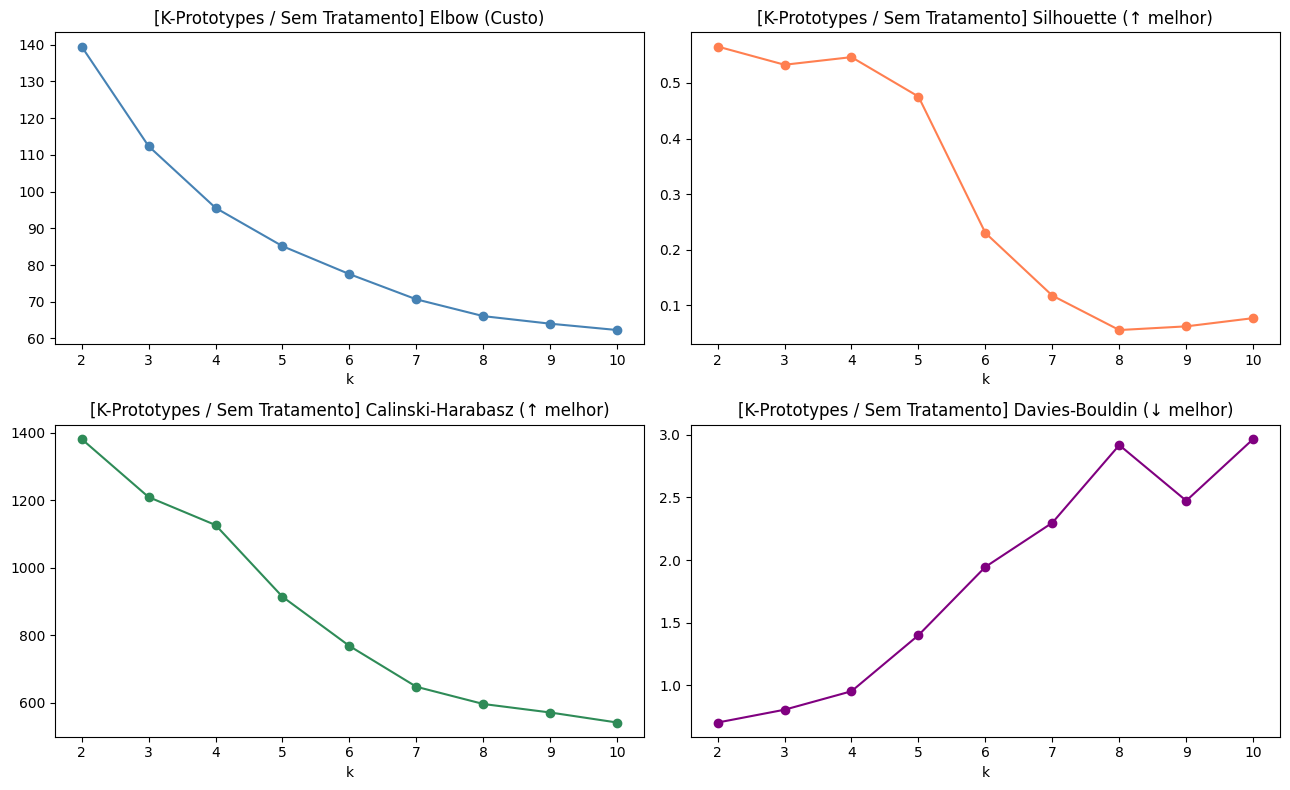

Melhor k por métrica (K-Prototypes / Sem Tratamento):
  Elbow (Custo)         : k = 4
  Silhouette            : k = 2
  Calinski-Harabasz     : k = 2
  Davies-Bouldin        : k = 2

→ k mais votado: 2


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

axes[0].plot(df_met_kp_s.index, df_met_kp_s['Custo (Elbow)'], marker='o', color='steelblue')
axes[0].set_title('[K-Prototypes / Sem Tratamento] Elbow (Custo)')
axes[0].set_xlabel('k')

axes[1].plot(df_met_kp_s.index, df_met_kp_s['Silhouette'], marker='o', color='coral')
axes[1].set_title('[K-Prototypes / Sem Tratamento] Silhouette (↑ melhor)')
axes[1].set_xlabel('k')

axes[2].plot(df_met_kp_s.index, df_met_kp_s['Calinski-Harabasz'], marker='o', color='seagreen')
axes[2].set_title('[K-Prototypes / Sem Tratamento] Calinski-Harabasz (↑ melhor)')
axes[2].set_xlabel('k')

axes[3].plot(df_met_kp_s.index, df_met_kp_s['Davies-Bouldin'], marker='o', color='purple')
axes[3].set_title('[K-Prototypes / Sem Tratamento] Davies-Bouldin (↓ melhor)')
axes[3].set_xlabel('k')

plt.tight_layout()
plt.show()

# Votação
votos_kp_s = {
    'Elbow (Custo)'     : df_met_kp_s['Custo (Elbow)'].diff().diff().abs().idxmax(),
    'Silhouette'        : df_met_kp_s['Silhouette'].idxmax(),
    'Calinski-Harabasz' : df_met_kp_s['Calinski-Harabasz'].idxmax(),
    'Davies-Bouldin'    : df_met_kp_s['Davies-Bouldin'].idxmin(),
}
print('Melhor k por métrica (K-Prototypes / Sem Tratamento):')
from collections import Counter
for met, k in votos_kp_s.items():
    print(f'  {met:22s}: k = {k}')
K_KP_S = Counter(votos_kp_s.values()).most_common(1)[0][0]
print(f'\n→ k mais votado: {K_KP_S}')

### 1.3.2 Treinamento com o k escolhido

In [ ]:
kp_s = KPrototypes(n_clusters=K_KP_S, init='Cao', random_state=42, n_init=5, verbose=0)
labels_kp_s = kp_s.fit_predict(X_s_kp, categorical=cat_idx_s)

print(f'K-Prototypes [Sem Tratamento] — k={K_KP_S}')
print('Distribuição dos clusters:')
print(pd.Series(labels_kp_s).value_counts().sort_index())

print('\nMétricas (parte numérica):')
print(f'  Silhouette        : {silhouette_score(X_s_kp_num, labels_kp_s):.4f}')
print(f'  Calinski-Harabasz : {calinski_harabasz_score(X_s_kp_num, labels_kp_s):.4f}')
print(f'  Davies-Bouldin    : {davies_bouldin_score(X_s_kp_num, labels_kp_s):.4f}')

print('\nDistâncias:')
intra_kp_s, inter_kp_s = distancias_intra_inter(X_s_kp_num, labels_kp_s)

K-Prototypes [Sem Tratamento] — k=2
Distribuição dos clusters:
0    491
1    400
Name: count, dtype: int64

Métricas (parte numérica):
  Silhouette        : 0.5656
  Calinski-Harabasz : 1381.8856
  Davies-Bouldin    : 0.7011

Distâncias:
  Distância Intra-cluster (média): 0.2736
  Distância Inter-cluster (média entre centróides): 0.7806


### 1.3.3 Árvore de rotulação e extração de regras


=== Regras da Árvore — K-Prototypes / Sem Tratamento ===
|--- Pclass <= 0.75
|   |--- class: 1
|--- Pclass >  0.75
|   |--- class: 0



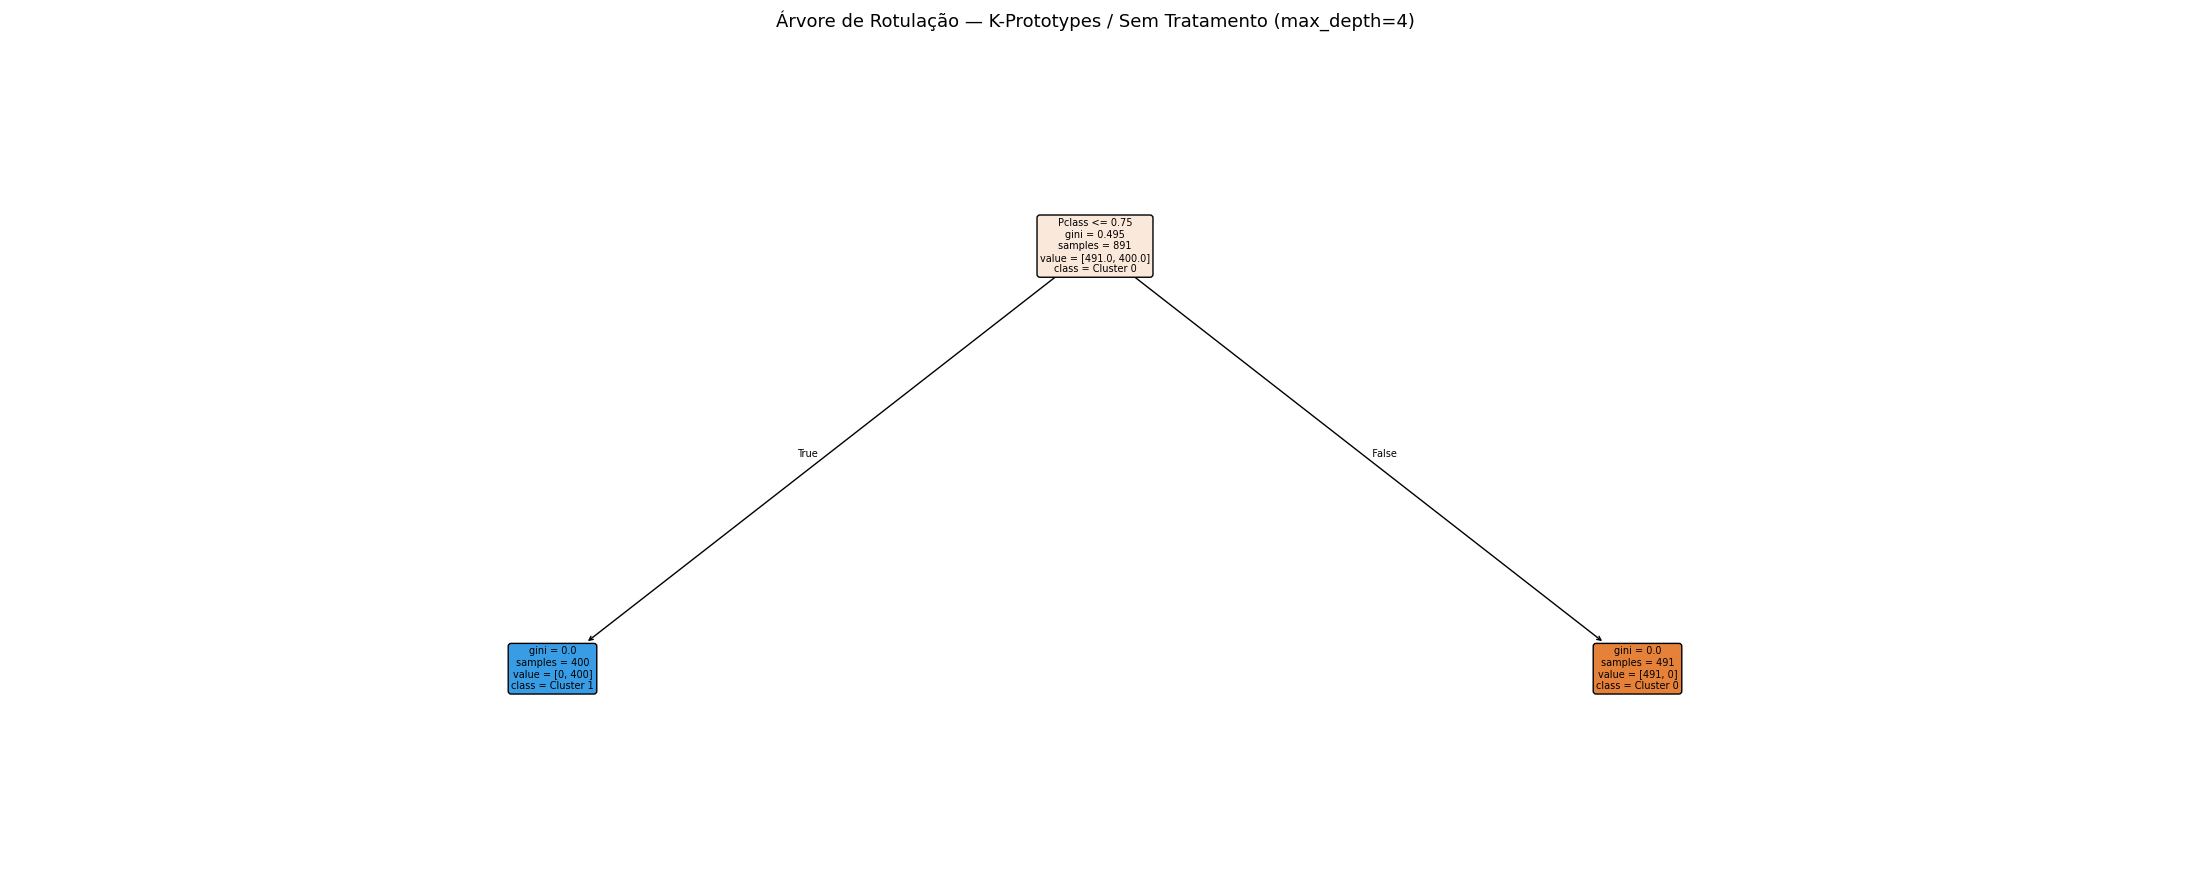

In [ ]:
dt_kp_s = arvore_de_rotulacao(
    X_s, labels_kp_s, feature_names_s,
    titulo='K-Prototypes / Sem Tratamento'
)

### 1.3.4 Análise dos clusters

In [ ]:
df_s_analise['Cluster_KP'] = labels_kp_s
print('Perfil médio por cluster (K-Prototypes / Sem Tratamento):')
display(df_s_analise.groupby('Cluster_KP').mean(numeric_only=True).round(2))

Perfil médio por cluster (K-Prototypes / Sem Tratamento):


,Pclass,Age,SibSp,Parch,Fare,Cluster_KM
Cluster_KP,,,,,,
0,3.00,25.93,0.62,0.39,13.68,2.10
1,1.46,33.57,0.41,0.37,54.95,4.97



--- Cluster 0 (491 pontos, 55.1% da base) ---
  Variáveis numéricas mais distintivas (|z-score| da média geral):
    Pclass         : média no cluster = 3.00 | média geral = 2.31 | z = 0.83
    Fare           : média no cluster = 13.68 | média geral = 32.20 | z = 0.37
    Age            : média no cluster = 25.93 | média geral = 29.36 | z = 0.26
  Categorias predominantes:
    Sex            : male (70.7% do cluster)
    Embarked       : S (71.9% do cluster)

--- Cluster 1 (400 pontos, 44.9% da base) ---
  Variáveis numéricas mais distintivas (|z-score| da média geral):
    Pclass         : média no cluster = 1.46 | média geral = 2.31 | z = 1.02
    Fare           : média no cluster = 54.95 | média geral = 32.20 | z = 0.46
    Age            : média no cluster = 33.57 | média geral = 29.36 | z = 0.32
  Categorias predominantes:
    Sex            : male (57.5% do cluster)
    Embarked       : S (73.2% do cluster)


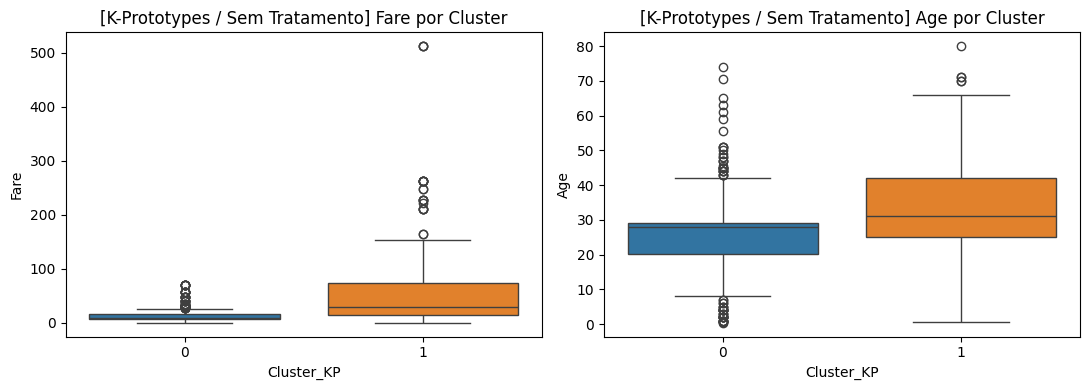

=== Validação a posteriori com Survived — K-Prototypes / Sem Tratamento ===


Survived,0,1,Total
Cluster,,,
0,372,119,491
1,177,223,400
Total,549,342,891



Taxa de sobrevivência por cluster:


,Taxa de Sobrevivência
Cluster,
0,0.242
1,0.558


(Survived    0    1  Total
 Cluster                  
 0         372  119    491
 1         177  223    400
 Total     549  342    891,
 Cluster
 0    0.242363
 1    0.557500
 Name: Taxa de Sobrevivência, dtype: float64)

In [ ]:
perfil_cluster(
    df_s_analise, 'Cluster_KP',
    num_cols=['Age', 'Fare', 'SibSp', 'Parch', 'Pclass'],
    cat_cols=['Sex', 'Embarked']
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df_s_analise, x='Cluster_KP', y='Fare', ax=axes[0], palette='tab10')
axes[0].set_title('[K-Prototypes / Sem Tratamento] Fare por Cluster')
sns.boxplot(data=df_s_analise, x='Cluster_KP', y='Age', ax=axes[1], palette='tab10')
axes[1].set_title('[K-Prototypes / Sem Tratamento] Age por Cluster')
plt.tight_layout()
plt.show()

validar_com_survived(labels_kp_s, y_survived, titulo='K-Prototypes / Sem Tratamento')

## 1.4 DBSCAN — sem tratamento

### 1.4.1 Escolha de eps com curva k-dist

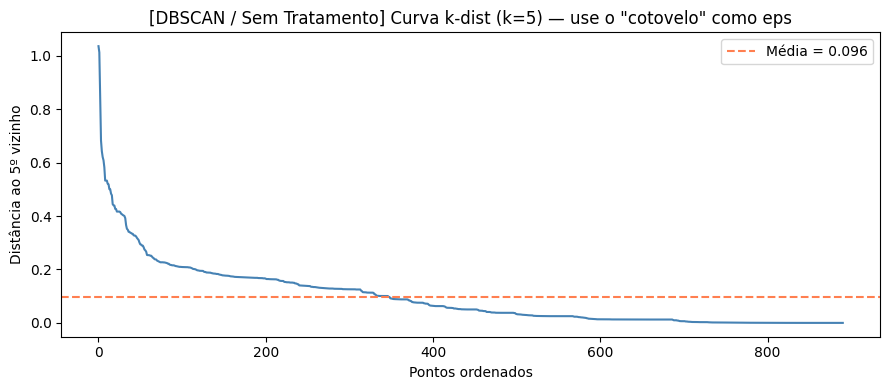

In [ ]:
from sklearn.neighbors import NearestNeighbors

# Curva de distância ao k-ésimo vizinho mais próximo (k = min_samples)
MIN_SAMPLES = 5
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_s)
dists, _ = nbrs.kneighbors(X_s)
kth_dist  = np.sort(dists[:, -1])[::-1]

plt.figure(figsize=(9, 4))
plt.plot(kth_dist, color='steelblue')
plt.axhline(y=kth_dist.mean(), color='coral', linestyle='--', label=f'Média = {kth_dist.mean():.3f}')
plt.title(f'[DBSCAN / Sem Tratamento] Curva k-dist (k={MIN_SAMPLES}) — use o "cotovelo" como eps')
plt.xlabel('Pontos ordenados')
plt.ylabel(f'Distância ao {MIN_SAMPLES}º vizinho')
plt.legend()
plt.tight_layout()
plt.show()

eps=0.10 | clusters=22 | ruído=310 | Silhouette=0.0338
eps=0.15 | clusters=21 | ruído=190 | Silhouette=0.3139
eps=0.20 | clusters=17 | ruído=69 | Silhouette=0.5394
eps=0.25 | clusters=15 | ruído=38 | Silhouette=0.5513
eps=0.30 | clusters=15 | ruído=35 | Silhouette=0.5529
eps=0.35 | clusters=14 | ruído=26 | Silhouette=0.5555
eps=0.40 | clusters=14 | ruído=17 | Silhouette=0.5620
eps=0.45 | clusters=14 | ruído=10 | Silhouette=0.5583
eps=0.50 | clusters=13 | ruído=10 | Silhouette=0.5647
eps=0.55 | clusters=6 | ruído=4 | Silhouette=0.6225
eps=0.60 | clusters=6 | ruído=1 | Silhouette=0.6188
eps=0.65 | clusters=6 | ruído=0 | Silhouette=0.6291
eps=0.70 | clusters=6 | ruído=0 | Silhouette=0.6291
eps=0.75 | clusters=6 | ruído=0 | Silhouette=0.6291
eps=0.80 | clusters=6 | ruído=0 | Silhouette=0.6291
eps=0.85 | clusters=6 | ruído=0 | Silhouette=0.6291
eps=0.90 | clusters=6 | ruído=0 | Silhouette=0.6291
eps=0.95 | clusters=6 | ruído=0 | Silhouette=0.6291
eps=1.00 | clusters=6 | ruído=0 | Silhouette

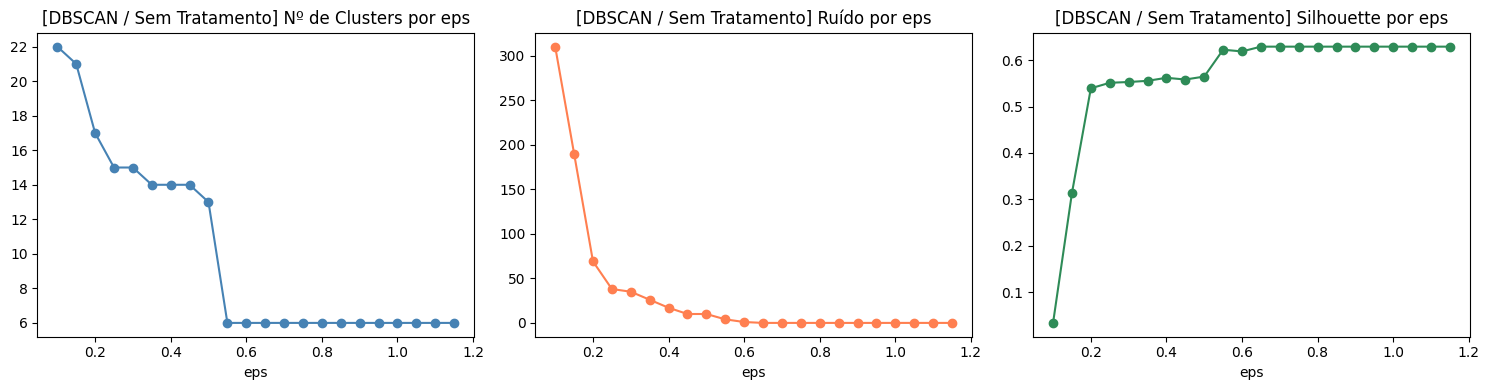

In [ ]:
# Varredura de eps para encontrar melhor Silhouette
eps_vals = np.arange(0.1, 1.2, 0.05)
resultados_dbscan_s = []

for eps in eps_vals:
    db = DBSCAN(eps=eps, min_samples=MIN_SAMPLES)
    lbs = db.fit_predict(X_s)
    n_clusters = len(set(lbs)) - (1 if -1 in lbs else 0)
    n_noise    = (lbs == -1).sum()
    if n_clusters > 1:
        sil = silhouette_score(X_s, lbs)
    else:
        sil = -1
    resultados_dbscan_s.append({
        'eps': round(eps, 2), 'n_clusters': n_clusters,
        'n_noise': n_noise, 'Silhouette': sil
    })
    print(f'eps={eps:.2f} | clusters={n_clusters} | ruído={n_noise} | Silhouette={sil:.4f}')

df_dbscan_s = pd.DataFrame(resultados_dbscan_s)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(df_dbscan_s['eps'], df_dbscan_s['n_clusters'], marker='o', color='steelblue')
axes[0].set_title('[DBSCAN / Sem Tratamento] Nº de Clusters por eps')
axes[0].set_xlabel('eps')
axes[1].plot(df_dbscan_s['eps'], df_dbscan_s['n_noise'], marker='o', color='coral')
axes[1].set_title('[DBSCAN / Sem Tratamento] Ruído por eps')
axes[1].set_xlabel('eps')
axes[2].plot(df_dbscan_s['eps'], df_dbscan_s['Silhouette'], marker='o', color='seagreen')
axes[2].set_title('[DBSCAN / Sem Tratamento] Silhouette por eps')
axes[2].set_xlabel('eps')
plt.tight_layout()
plt.show()

### 1.4.2 Treinamento com eps escolhido

In [ ]:
# Ajuste EPS_S conforme o cotovelo da curva k-dist e os gráficos acima
EPS_S = df_dbscan_s.loc[df_dbscan_s['Silhouette'].idxmax(), 'eps']
print(f'eps selecionado automaticamente (melhor Silhouette): {EPS_S}')
# Para sobrescrever: EPS_S = 0.5

db_s = DBSCAN(eps=EPS_S, min_samples=MIN_SAMPLES)
labels_db_s = db_s.fit_predict(X_s)

n_clusters_db_s = len(set(labels_db_s)) - (1 if -1 in labels_db_s else 0)
n_noise_db_s    = (labels_db_s == -1).sum()

print(f'\nDBSCAN [Sem Tratamento] — eps={EPS_S} | min_samples={MIN_SAMPLES}')
print(f'Clusters encontrados : {n_clusters_db_s}')
print(f'Pontos de ruído      : {n_noise_db_s} ({n_noise_db_s/len(labels_db_s):.1%})')
print('Distribuição:', pd.Series(labels_db_s).value_counts().sort_index().to_dict())

if n_clusters_db_s > 1:
    mask_db_s = labels_db_s >= 0
    print(f'\nMétricas (excluindo ruído):')
    print(f'  Silhouette        : {silhouette_score(X_s[mask_db_s], labels_db_s[mask_db_s]):.4f}')
    print(f'  Calinski-Harabasz : {calinski_harabasz_score(X_s[mask_db_s], labels_db_s[mask_db_s]):.4f}')
    print(f'  Davies-Bouldin    : {davies_bouldin_score(X_s[mask_db_s], labels_db_s[mask_db_s]):.4f}')
    print('\nDistâncias:')
    intra_db_s, inter_db_s = distancias_intra_inter(X_s, labels_db_s)

eps selecionado automaticamente (melhor Silhouette): 0.65

DBSCAN [Sem Tratamento] — eps=0.65 | min_samples=5
Clusters encontrados : 6
Pontos de ruído      : 0 (0.0%)
Distribuição: {0: 441, 1: 73, 2: 205, 3: 41, 4: 36, 5: 95}

Métricas (excluindo ruído):
  Silhouette        : 0.6291
  Calinski-Harabasz : 716.9859
  Davies-Bouldin    : 0.6159

Distâncias:
  Distância Intra-cluster (média): 0.3793
  Distância Inter-cluster (média entre centróides): 1.6858


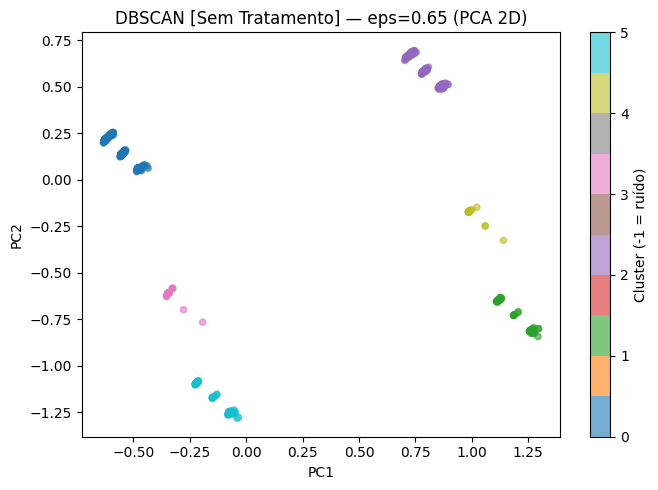

In [ ]:
# Visualização
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_s_2d[:, 0], X_s_2d[:, 1],
                      c=labels_db_s, cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Cluster (-1 = ruído)')
plt.title(f'DBSCAN [Sem Tratamento] — eps={EPS_S} (PCA 2D)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout()
plt.show()

### 1.4.3 Árvore de rotulação e extração de regras


=== Regras da Árvore — DBSCAN / Sem Tratamento ===
|--- Sex_female <= 0.50
|   |--- Embarked_S <= 0.50
|   |   |--- Embarked_C <= 0.50
|   |   |   |--- class: 3
|   |   |--- Embarked_C >  0.50
|   |   |   |--- class: 5
|   |--- Embarked_S >  0.50
|   |   |--- class: 0
|--- Sex_female >  0.50
|   |--- Embarked_S <= 0.50
|   |   |--- Embarked_Q <= 0.50
|   |   |   |--- class: 1
|   |   |--- Embarked_Q >  0.50
|   |   |   |--- class: 4
|   |--- Embarked_S >  0.50
|   |   |--- class: 2



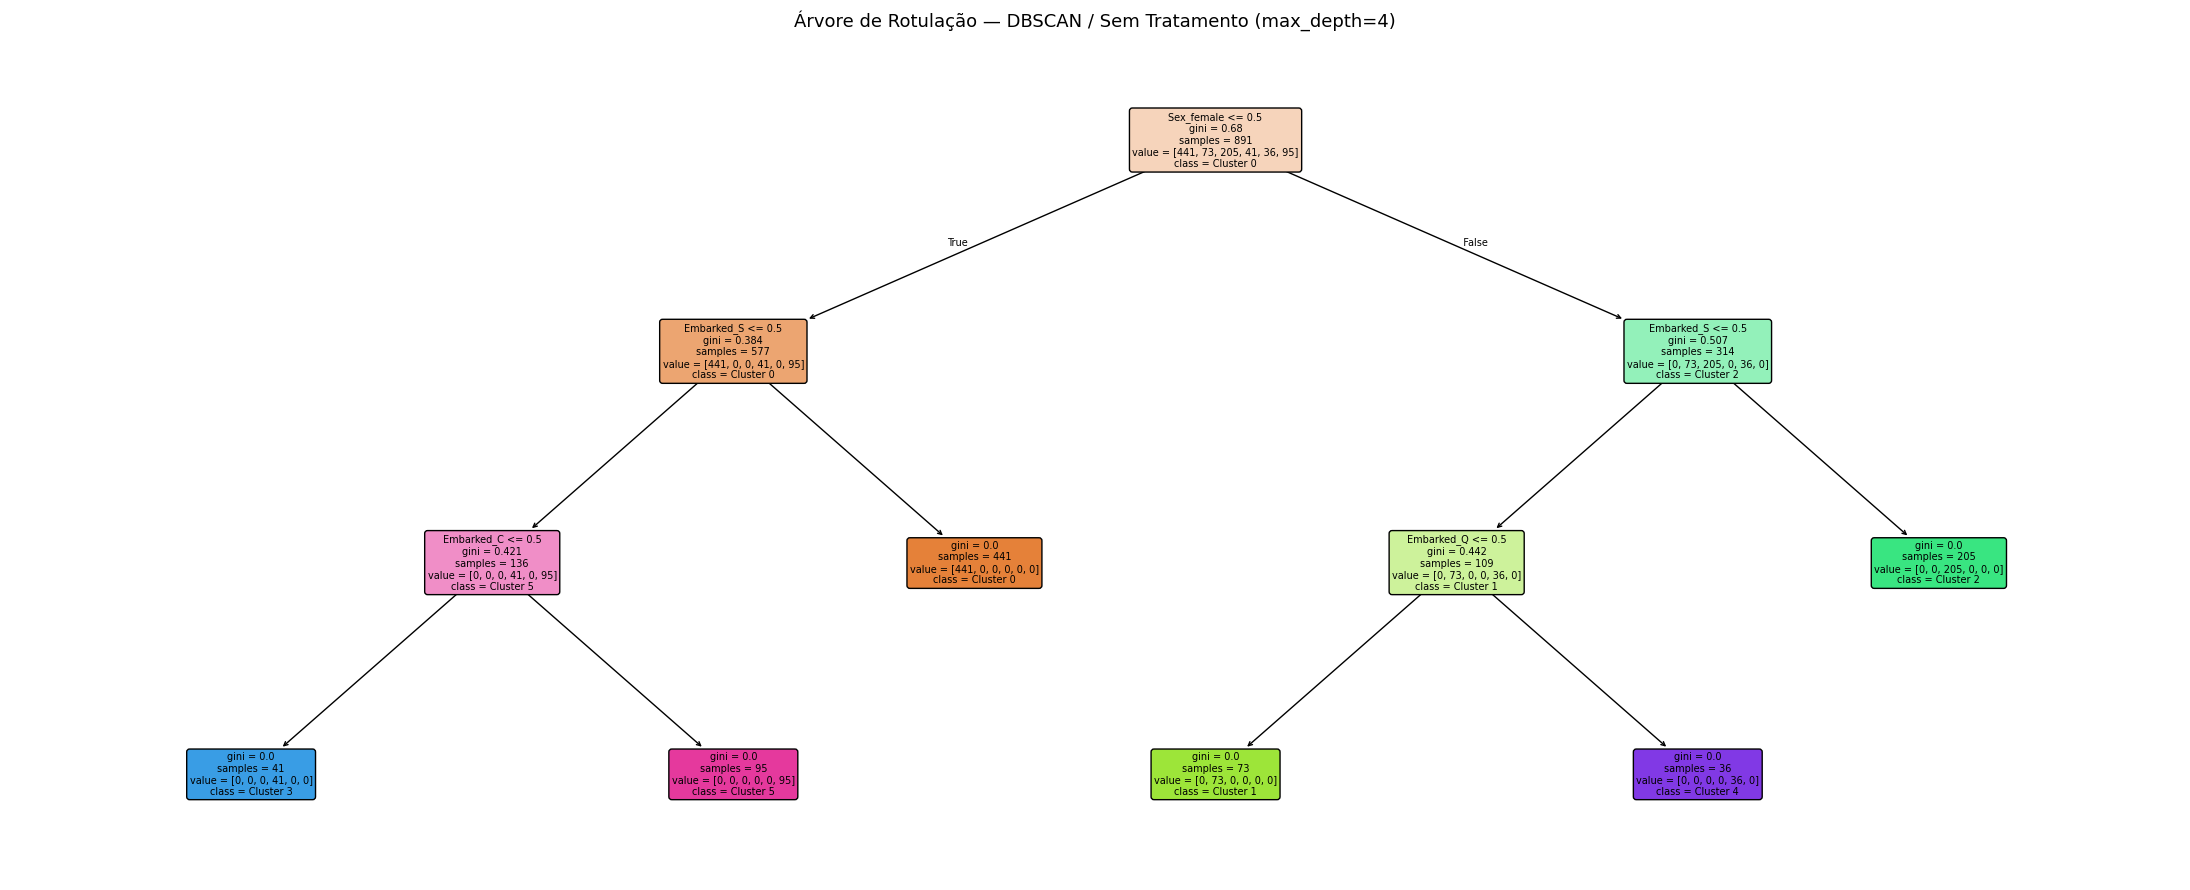

In [ ]:
if n_clusters_db_s > 1:
    dt_db_s = arvore_de_rotulacao(
        X_s, labels_db_s, feature_names_s,
        titulo='DBSCAN / Sem Tratamento'
    )
else:
    print('DBSCAN encontrou apenas 1 cluster — ajuste eps para gerar a árvore.')

### 1.4.4 Análise dos clusters

In [ ]:
df_s_analise['Cluster_DB'] = labels_db_s

if n_clusters_db_s > 1:
    print('Perfil médio por cluster (DBSCAN / Sem Tratamento, -1 = ruído):')
    display(df_s_analise.groupby('Cluster_DB').mean(numeric_only=True).round(2))

    perfil_cluster(
        df_s_analise[df_s_analise['Cluster_DB'] >= 0], 'Cluster_DB',
        num_cols=['Age', 'Fare', 'SibSp', 'Parch', 'Pclass'],
        cat_cols=['Sex', 'Embarked']
    )
    validar_com_survived(labels_db_s, y_survived, titulo='DBSCAN / Sem Tratamento')
else:
    print('DBSCAN encontrou apenas 1 cluster — sem sentido comparar perfis.')

Perfil médio por cluster (DBSCAN / Sem Tratamento, -1 = ruído):


,Pclass,Age,SibSp,Parch,Fare,Cluster_KM,Cluster_KP
Cluster_DB,,,,,,,
0,2.42,29.91,0.45,0.24,21.71,2.39,0.40
1,1.73,28.29,0.55,0.49,75.17,4.47,0.68
2,2.19,28.01,0.83,0.78,39.14,2.71,0.57
3,2.93,29.15,0.61,0.12,13.84,7.00,0.05
4,2.89,26.76,0.22,0.22,12.63,3.00,0.08
5,2.01,31.63,0.26,0.26,48.26,7.23,0.55



--- Cluster 0 (441 pontos, 49.5% da base) ---
  Variáveis numéricas mais distintivas (|z-score| da média geral):
    Fare           : média no cluster = 21.71 | média geral = 32.20 | z = 0.21
    Parch          : média no cluster = 0.24 | média geral = 0.38 | z = 0.18
    Pclass         : média no cluster = 2.42 | média geral = 2.31 | z = 0.14
  Categorias predominantes:
    Sex            : male (100.0% do cluster)
    Embarked       : S (100.0% do cluster)

--- Cluster 1 (73 pontos, 8.2% da base) ---
  Variáveis numéricas mais distintivas (|z-score| da média geral):
    Fare           : média no cluster = 75.17 | média geral = 32.20 | z = 0.86
    Pclass         : média no cluster = 1.73 | média geral = 2.31 | z = 0.70
    Parch          : média no cluster = 0.49 | média geral = 0.38 | z = 0.14
  Categorias predominantes:
    Sex            : female (100.0% do cluster)
    Embarked       : C (100.0% do cluster)

--- Cluster 2 (205 pontos, 23.0% da base) ---
  Variáveis numéricas mai

Survived,0,1,Total
Cluster,,,
0,364,77,441
1,9,64,73
2,63,142,205
3,38,3,41
4,9,27,36
5,66,29,95
Total,549,342,891



Taxa de sobrevivência por cluster:


,Taxa de Sobrevivência
Cluster,
0,0.175
1,0.877
2,0.693
3,0.073
4,0.750
5,0.305


---
# **PARTE 2 — Pré-processamento Completo**

### **Análise Exploratória**

In [ ]:
df_analysis = df_raw.copy()
print(df_analysis.shape)
print(df_analysis.dtypes)
display(df_analysis.describe())
print('\nValores nulos por coluna:')
print(df_analysis.isnull().sum())

(891, 11)
PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Valores nulos por coluna:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


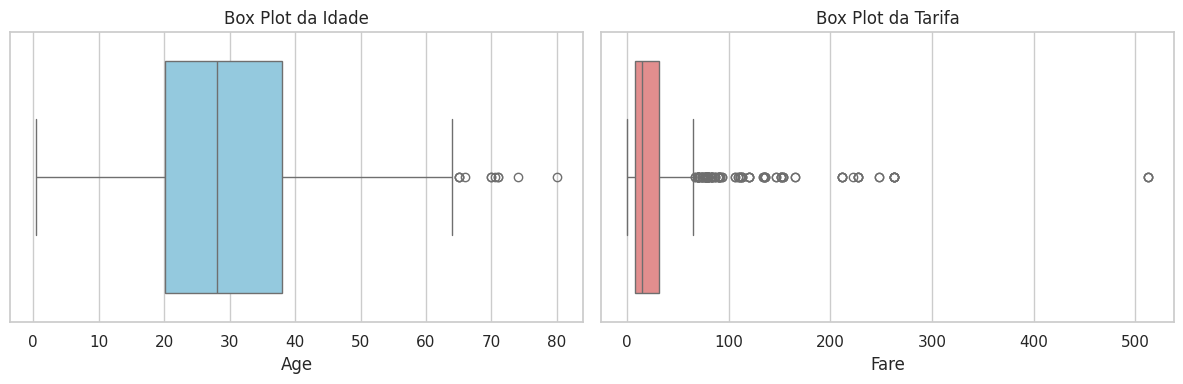

In [ ]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df_analysis['Age'].dropna(), ax=axes[0], color='skyblue')
axes[0].set_title('Box Plot da Idade')
sns.boxplot(x=df_analysis['Fare'], ax=axes[1], color='lightcoral')
axes[1].set_title('Box Plot da Tarifa')
plt.tight_layout(); plt.show()

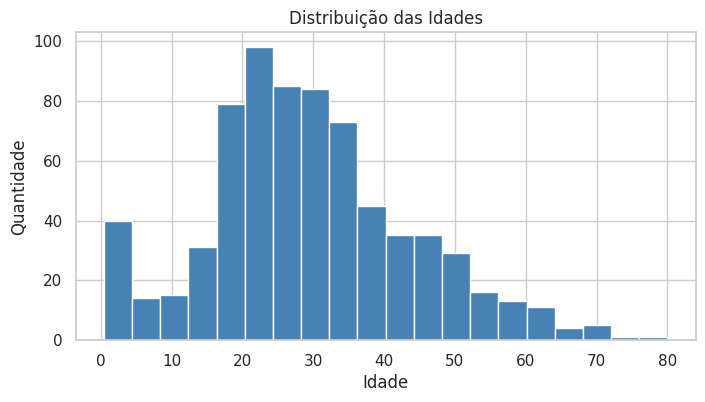

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df_analysis['Age'].dropna(), bins=20, color='steelblue', edgecolor='white')
plt.xlabel('Idade'); plt.ylabel('Quantidade')
plt.title('Distribuição das Idades')
plt.show()

### **Pré-processamento**

In [ ]:
CABINE_LETRAS       = list('TGFEDCBA')
COLUNAS_INUTEIS     = ['PassengerId', 'Ticket']
COLUNAS_NUMERICAS   = ['Fare', 'SibSp', 'Parch']
COLUNAS_CATEGORICAS = ['Pclass', 'Name', 'Sex', 'Cabin', 'Embarked', 'Age_cut']

def extrair_titulo(name: str) -> str:
    rare_patterns = ["Mrs ", "Mr ", "Don", "Jonkheer"]
    title_map = [
        ("Mr.",      "Mr."),   ("Mrs.",    "Mrs."),
        ("Miss.",    "Miss."), ("Master.", "Master."),
        ("Dr.",      "Dr."),   ("Rev.",    "Rev."),
        ("Col.",     "Col."),  ("Major.",  "Major."),
        ("Mlle.",    "Mlle."), ("Capt.",   "Ms."),
        ("Ms.",      "Ms."),   ("Mme.",    "Mme."),
        ("Countess", "Countess"),
    ]
    for pattern in rare_patterns:
        if pattern in name: return "Rare"
    for pattern, title in title_map:
        if pattern in name: return title
    return "Unknown"

def extrair_letra_cabine(cabine):
    if pd.isna(cabine): return 'NOT_INFORMED'
    for letra in CABINE_LETRAS:
        if letra in str(cabine): return letra
    return 'NOT_INFORMED'

def preprocessar(df_input, scaler=None, fit_scaler=False, colunas_treino=None):
    df = df_input.copy().reset_index(drop=True)
    df['Name']     = df['Name'].apply(extrair_titulo)
    df['Cabin']    = df['Cabin'].apply(extrair_letra_cabine)
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    mediana_por_titulo = df.groupby('Name')['Age'].median()
    df['Age'] = df.apply(
        lambda row: mediana_por_titulo[row['Name']] if pd.isna(row['Age']) else row['Age'], axis=1
    )
    df['Age_cut'] = pd.cut(df['Age'], bins=[0, 18, 25, 40, float('inf')],
                            labels=['0-18', '18-25', '25-40', '40+'],
                            right=True, include_lowest=True)
    df = df.drop(columns=COLUNAS_INUTEIS + ['Age'])
    if fit_scaler:
      scaler = MinMaxScaler()

      # Limites baseados nos quintis para reduzir o efeito de outliers no Fare
      fare_min = df['Fare'].quantile(0.2)  # maior termo do 1º quintil
      fare_max = df['Fare'].quantile(0.8)  # menor termo do último quintil

      # guarda os limites no próprio objeto scaler para reutilizar no transform
      scaler.fare_min_ = fare_min
      scaler.fare_max_ = fare_max

      df['Fare_norm'] = ((df['Fare'] - fare_min) / (fare_max - fare_min)).clip(0, 1)

    else:
      fare_min = scaler.fare_min_
      fare_max = scaler.fare_max_

      df['Fare_norm'] = ((df['Fare'] - fare_min) / (fare_max - fare_min)).clip(0, 1)

    df = df.drop(columns='Fare')
    df = pd.get_dummies(df, columns=COLUNAS_CATEGORICAS)
    if colunas_treino is not None:
        df = df.reindex(columns=colunas_treino, fill_value=0)
    return df, scaler

In [ ]:
df_treinamento, scaler = preprocessar(df_raw, fit_scaler=True)
print(f'Shape após pré-processamento: {df_treinamento.shape}')
display(df_treinamento)

Shape após pré-processamento: (891, 37)


,SibSp,Parch,Fare_norm,Pclass_1,Pclass_2,Pclass_3,Name_Col.,Name_Countess,Name_Dr.,Name_Major.,...,Cabin_G,Cabin_NOT_INFORMED,Cabin_T,Embarked_C,Embarked_Q,Embarked_S,Age_cut_0-18,Age_cut_18-25,Age_cut_25-40,Age_cut_40+
0,1,0,0.000000,False,False,True,False,False,False,False,...,False,True,False,False,False,True,False,True,False,False
1,1,0,1.000000,True,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,0,0.002224,False,False,True,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False
3,1,0,1.000000,True,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
4,0,0,0.006151,False,False,True,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,0,0.161648,False,True,False,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False
887,0,0,0.695680,True,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
888,1,2,0.489921,False,False,True,False,False,False,False,...,False,True,False,False,False,True,False,True,False,False
889,0,0,0.695680,True,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False


---
# **PARTE 3 — Exploração dos Algoritmos**


### 3.1 Preparação da base para os algoritmos

A `df_treinamento` (saída da Parte 2) já está com codificação one-hot e escalonamento aplicados — pode ser usada diretamente por **K-Means** e **DBSCAN** (baseados em distância euclidiana).

Para o **K-Prototypes**, que exige colunas categóricas em sua forma original (não one-hot), geramos uma versão paralela reaproveitando as mesmas funções de engenharia de atributos (`extrair_titulo`, `extrair_letra_cabine`, `Age_cut`, tratamento de `Fare`), mas sem o `get_dummies` final.

In [ ]:
# ---- Versão para K-Means / DBSCAN: já pronta (one-hot + normalização) ----
X_c = df_treinamento.astype(float).values
feature_names_c = df_treinamento.columns.tolist()

print(f'Shape para K-Means/DBSCAN: {X_c.shape}')
print(f'Features: {feature_names_c}')

Shape para K-Means/DBSCAN: (891, 37)
Features: ['SibSp', 'Parch', 'Fare_norm', 'Pclass_1', 'Pclass_2', 'Pclass_3', 'Name_Col.', 'Name_Countess', 'Name_Dr.', 'Name_Major.', 'Name_Master.', 'Name_Miss.', 'Name_Mlle.', 'Name_Mme.', 'Name_Mr.', 'Name_Mrs.', 'Name_Ms.', 'Name_Rare', 'Name_Rev.', 'Sex_female', 'Sex_male', 'Cabin_A', 'Cabin_B', 'Cabin_C', 'Cabin_D', 'Cabin_E', 'Cabin_F', 'Cabin_G', 'Cabin_NOT_INFORMED', 'Cabin_T', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Age_cut_0-18', 'Age_cut_18-25', 'Age_cut_25-40', 'Age_cut_40+']


In [ ]:
# ---- Versão para K-Prototypes: numéricas normalizadas + categóricas originais ----
def preprocessar_para_kp(df_input, fare_bounds=None, fit_scaler=False):
    """Mesma engenharia de atributos de `preprocessar`, mas mantém as
    colunas categóricas em sua forma original (sem one-hot), para uso no K-Prototypes."""
    df = df_input.copy().reset_index(drop=True)
    df['Name']     = df['Name'].apply(extrair_titulo)
    df['Cabin']    = df['Cabin'].apply(extrair_letra_cabine)
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    mediana_por_titulo = df.groupby('Name')['Age'].median()
    df['Age'] = df.apply(
        lambda row: mediana_por_titulo[row['Name']] if pd.isna(row['Age']) else row['Age'], axis=1
    )
    df['Age_cut'] = pd.cut(df['Age'], bins=[0, 18, 25, 40, float('inf')],
                            labels=['0-18', '18-25', '25-40', '40+'],
                            right=True, include_lowest=True).astype(str)
    df = df.drop(columns=COLUNAS_INUTEIS + ['Age'])

    if fit_scaler:
        fare_min = df['Fare'].quantile(0.2)
        fare_max = df['Fare'].quantile(0.8)
    else:
        fare_min, fare_max = fare_bounds
    df['Fare_norm'] = ((df['Fare'] - fare_min) / (fare_max - fare_min)).clip(0, 1)
    df = df.drop(columns='Fare')

    df['Pclass'] = df['Pclass'].astype(str)
    return df, (fare_min, fare_max)

df_c_kp_raw, _fare_bounds_c = preprocessar_para_kp(df_raw, fit_scaler=True)

NUM_COLS_C = ['SibSp', 'Parch', 'Fare_norm']
CAT_COLS_C = ['Pclass', 'Name', 'Sex', 'Cabin', 'Embarked', 'Age_cut']

df_c_kp = df_c_kp_raw.copy()
scaler_kp_c = MinMaxScaler()
df_c_kp[NUM_COLS_C] = scaler_kp_c.fit_transform(df_c_kp[NUM_COLS_C])

cat_idx_c = [df_c_kp.columns.tolist().index(c) for c in CAT_COLS_C]
X_c_kp = df_c_kp.values
print(f'Shape para K-Prototypes: {X_c_kp.shape} | cat_idx: {cat_idx_c}')

Shape para K-Prototypes: (891, 9) | cat_idx: [0, 1, 2, 5, 6, 7]


## 3.2 K-Means — pré-processamento completo

### 3.2.1 Escolha de k pelas métricas

,Inércia (Elbow),Silhouette,Calinski-Harabasz,Davies-Bouldin
k,,,,
2,3747.7889,0.4307,210.0121,1.2085
3,3070.0498,0.2594,226.0595,1.6027
4,2757.5393,0.2550,201.1046,1.6812
5,2500.1665,0.2520,188.9693,1.5775
6,2345.5037,0.2538,172.6335,1.6626
7,2186.1262,0.2367,164.9161,1.6709
8,2066.0979,0.2479,156.7276,1.5970
9,1951.3988,0.2443,151.5131,1.5781
10,1864.9705,0.2508,145.2964,1.4941


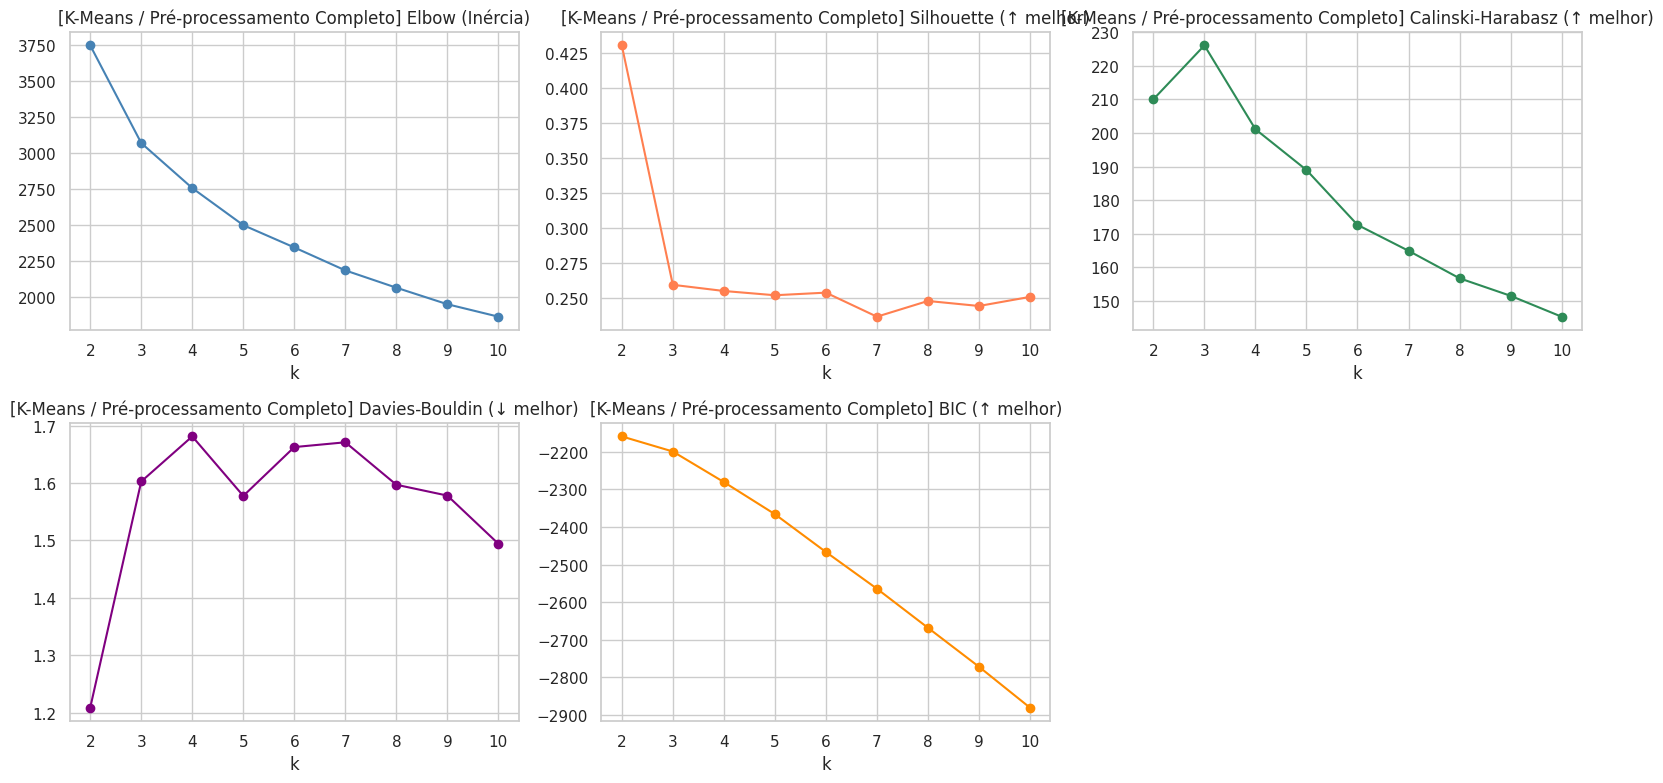

In [ ]:
df_met_km_c = calcular_metricas_k(X_c, k_range=range(2, 11))
bic_km_c    = bic_kmeans(X_c, k_range=range(2, 11))
display(df_met_km_c.round(4))
plotar_metricas(df_met_km_c, bic_km_c, titulo_prefix='[K-Means / Pré-processamento Completo] ')

In [ ]:
K_KM_C = resumo_votos(df_met_km_c, bic_km_c)

Melhor k por métrica:
  Elbow                 : k = 4
  Silhouette            : k = 2
  Calinski-Harabasz     : k = 3
  Davies-Bouldin        : k = 2
  BIC                   : k = 2

→ k mais votado pela maioria: 2 (3/5 métricas concordam)
   Atenção: as métricas não são unânimes. Divergências: {'Elbow': np.int64(4), 'Calinski-Harabasz': np.int64(3)}
   Isso é esperado em clustering — vale inspecionar os gráficos antes de decidir.


### 3.2.2 Treinamento com o k escolhido

In [ ]:
km_c = KMeans(n_clusters=K_KM_C, random_state=42, n_init=10)
labels_km_c = km_c.fit_predict(X_c)

print(f'K-Means [Pré-processamento Completo] — k={K_KM_C}')
print('Distribuição dos clusters:')
print(pd.Series(labels_km_c).value_counts().sort_index())

print('\nMétricas do modelo final:')
print(f'  Silhouette        : {silhouette_score(X_c, labels_km_c):.4f}')
print(f'  Calinski-Harabasz : {calinski_harabasz_score(X_c, labels_km_c):.4f}')
print(f'  Davies-Bouldin    : {davies_bouldin_score(X_c, labels_km_c):.4f}')

print('\nDistâncias:')
intra_km_c, inter_km_c = distancias_intra_inter(X_c, labels_km_c)

K-Means [Pré-processamento Completo] — k=2
Distribuição dos clusters:
0    822
1     69
Name: count, dtype: int64

Métricas do modelo final:
  Silhouette        : 0.4307
  Calinski-Harabasz : 210.0121
  Davies-Bouldin    : 1.2085

Distâncias:
  Distância Intra-cluster (média): 2.2535
  Distância Inter-cluster (média entre centróides): 3.7294


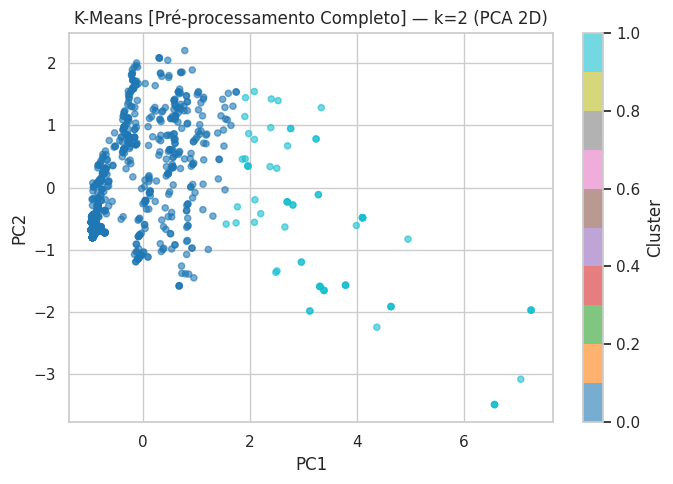

In [ ]:
# Visualização 2D (PCA para redução)
pca_c = PCA(n_components=2, random_state=42)
X_c_2d = pca_c.fit_transform(X_c)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_c_2d[:, 0], X_c_2d[:, 1], c=labels_km_c, cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-Means [Pré-processamento Completo] — k={K_KM_C} (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

### 3.2.3 Árvore de rotulação e extração de regras


=== Regras da Árvore — K-Means / Pré-processamento Completo ===
|--- SibSp <= 2.50
|   |--- Parch <= 2.50
|   |   |--- SibSp <= 1.50
|   |   |   |--- class: 0
|   |   |--- SibSp >  1.50
|   |   |   |--- Parch <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Parch >  0.50
|   |   |   |   |--- class: 1
|   |--- Parch >  2.50
|   |   |--- Fare_norm <= 0.45
|   |   |   |--- SibSp <= 1.00
|   |   |   |   |--- class: 0
|   |   |   |--- SibSp >  1.00
|   |   |   |   |--- class: 1
|   |   |--- Fare_norm >  0.45
|   |   |   |--- class: 1
|--- SibSp >  2.50
|   |--- class: 1



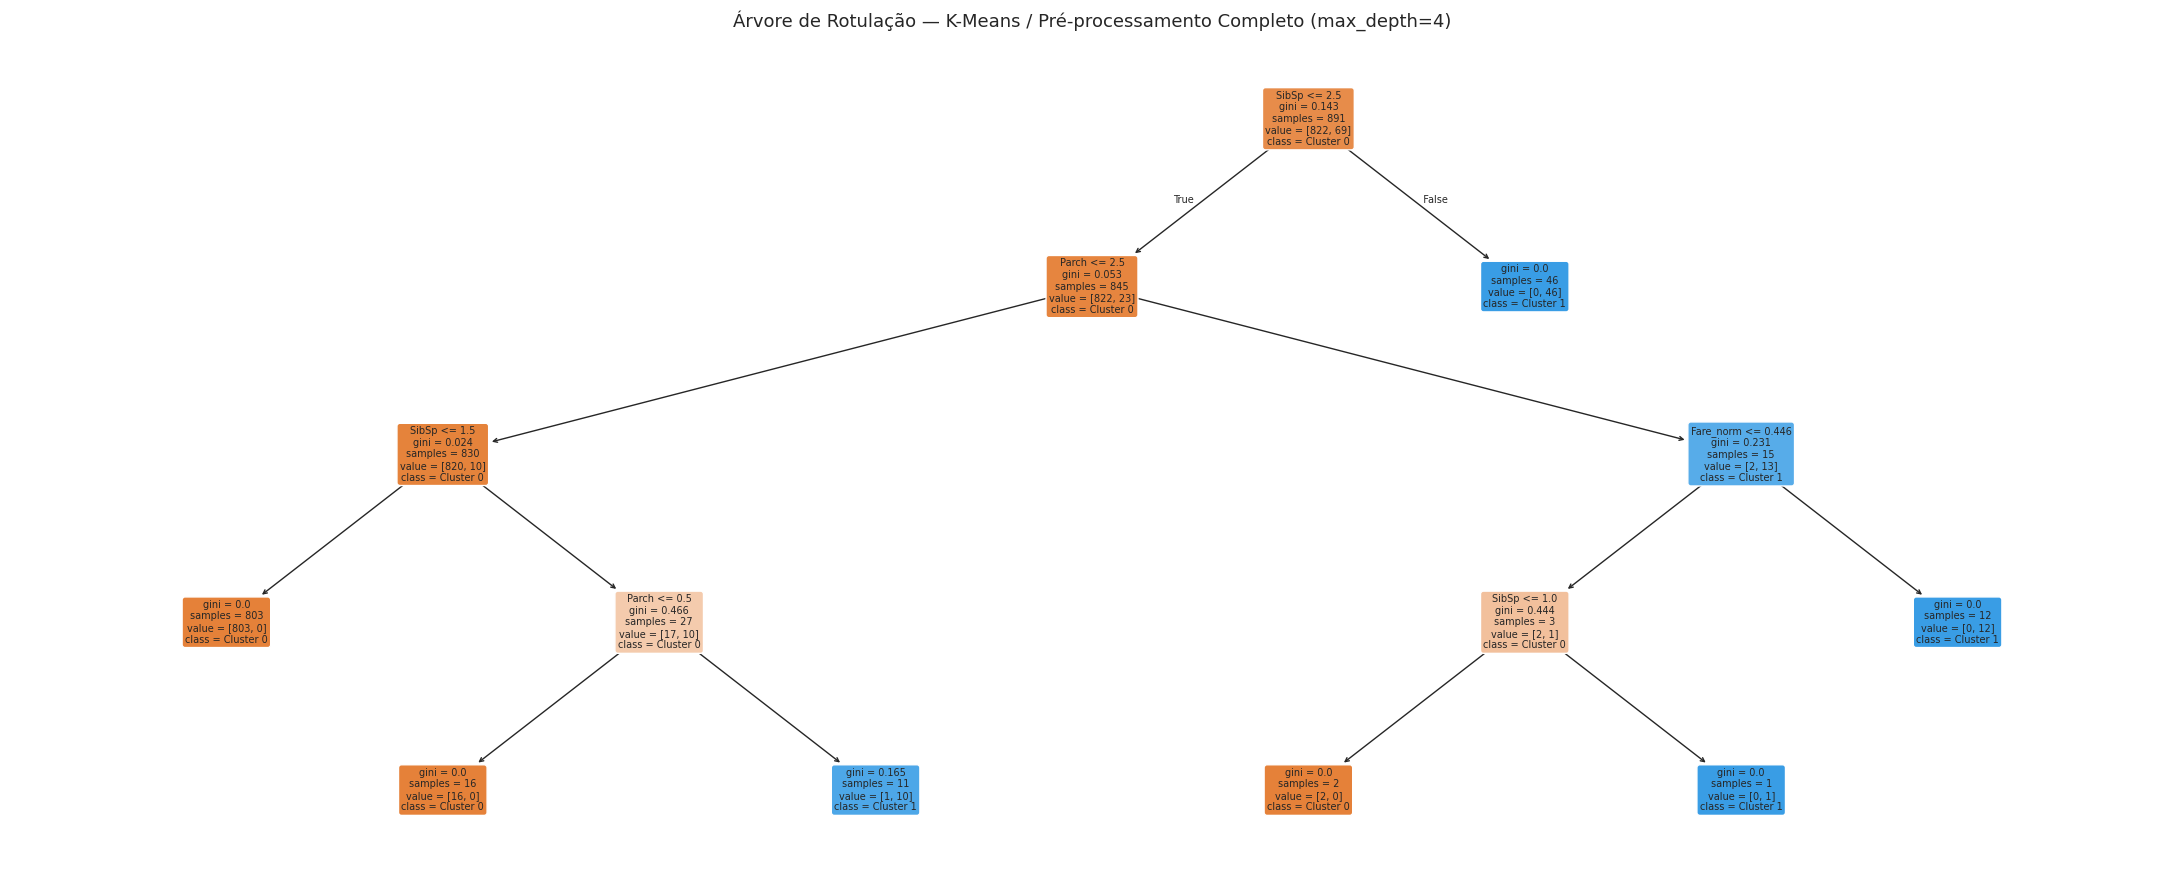

In [ ]:
dt_km_c = arvore_de_rotulacao(X_c, labels_km_c, feature_names_c, titulo='K-Means / Pré-processamento Completo')

### 3.2.4 Análise dos clusters

Perfil médio por cluster (K-Means / Pré-processamento Completo):


,SibSp,Parch,Fare_norm
Cluster_KM,,,
0,0.28,0.24,0.35
1,3.38,2.04,0.76


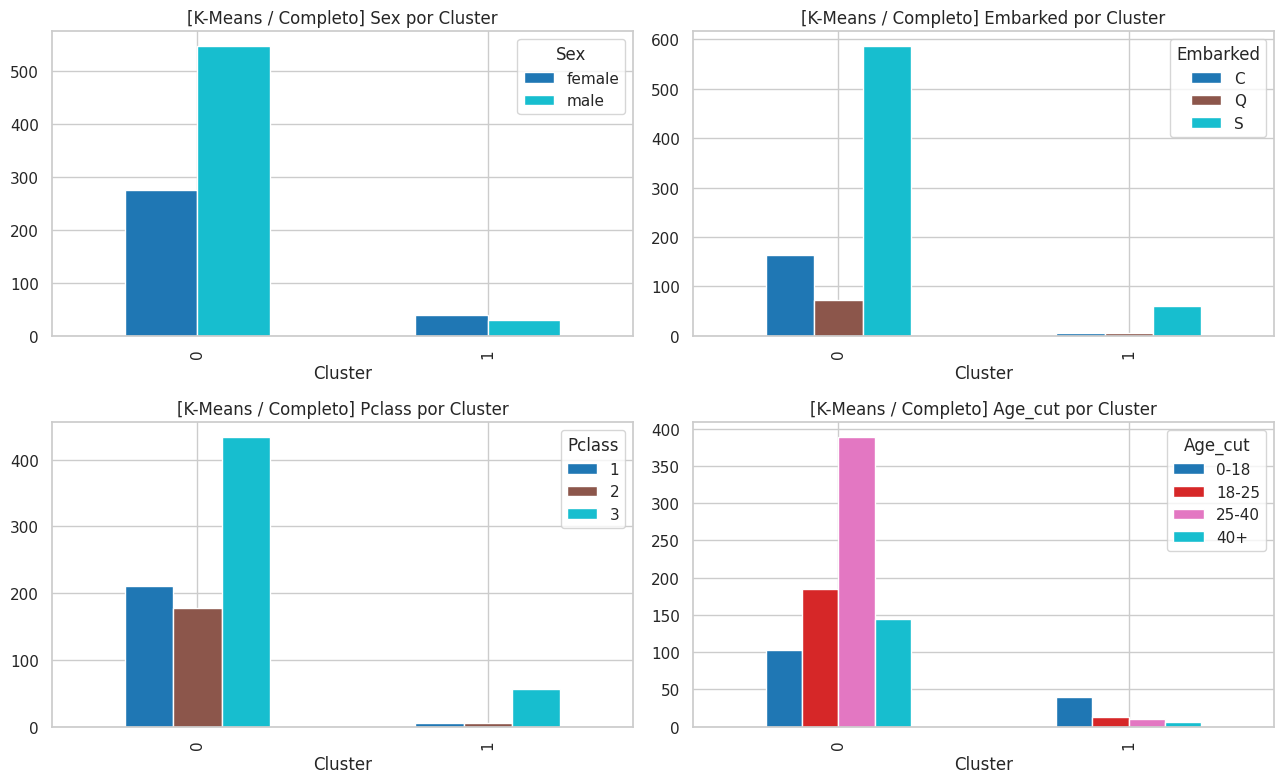

In [ ]:
df_c_analise = df_c_kp_raw.copy()
df_c_analise['Cluster_KM'] = labels_km_c

print('Perfil médio por cluster (K-Means / Pré-processamento Completo):')
display(df_c_analise.groupby('Cluster_KM').mean(numeric_only=True).round(2))

# Distribuição de variáveis categóricas por cluster
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

df_c_analise.groupby(['Cluster_KM', 'Sex']).size().unstack(fill_value=0).plot(
    kind='bar', ax=axes[0], colormap='tab10', edgecolor='white')
axes[0].set_title('[K-Means / Completo] Sex por Cluster')
axes[0].set_xlabel('Cluster')

df_c_analise.groupby(['Cluster_KM', 'Embarked']).size().unstack(fill_value=0).plot(
    kind='bar', ax=axes[1], colormap='tab10', edgecolor='white')
axes[1].set_title('[K-Means / Completo] Embarked por Cluster')
axes[1].set_xlabel('Cluster')

df_c_analise.groupby(['Cluster_KM', 'Pclass']).size().unstack(fill_value=0).plot(
    kind='bar', ax=axes[2], colormap='tab10', edgecolor='white')
axes[2].set_title('[K-Means / Completo] Pclass por Cluster')
axes[2].set_xlabel('Cluster')

df_c_analise.groupby(['Cluster_KM', 'Age_cut']).size().unstack(fill_value=0).plot(
    kind='bar', ax=axes[3], colormap='tab10', edgecolor='white')
axes[3].set_title('[K-Means / Completo] Age_cut por Cluster')
axes[3].set_xlabel('Cluster')

plt.tight_layout()
plt.show()


--- Cluster 0 (822 pontos, 92.3% da base) ---
  Variáveis numéricas mais distintivas (|z-score| da média geral):
    SibSp          : média no cluster = 0.28 | média geral = 0.52 | z = 0.22
    Parch          : média no cluster = 0.24 | média geral = 0.38 | z = 0.17
    Fare_norm      : média no cluster = 0.35 | média geral = 0.38 | z = 0.08
  Categorias predominantes:
    Sex            : male (66.5% do cluster)
    Embarked       : S (71.4% do cluster)
    Pclass         : 3 (52.8% do cluster)
    Age_cut        : 25-40 (47.3% do cluster)
    Name           : Mr. (61.1% do cluster)

--- Cluster 1 (69 pontos, 7.7% da base) ---
  Variáveis numéricas mais distintivas (|z-score| da média geral):
    SibSp          : média no cluster = 3.38 | média geral = 0.52 | z = 2.59
    Parch          : média no cluster = 2.04 | média geral = 0.38 | z = 2.06
    Fare_norm      : média no cluster = 0.76 | média geral = 0.38 | z = 0.94
  Categorias predominantes:
    Sex            : female (56.5% do

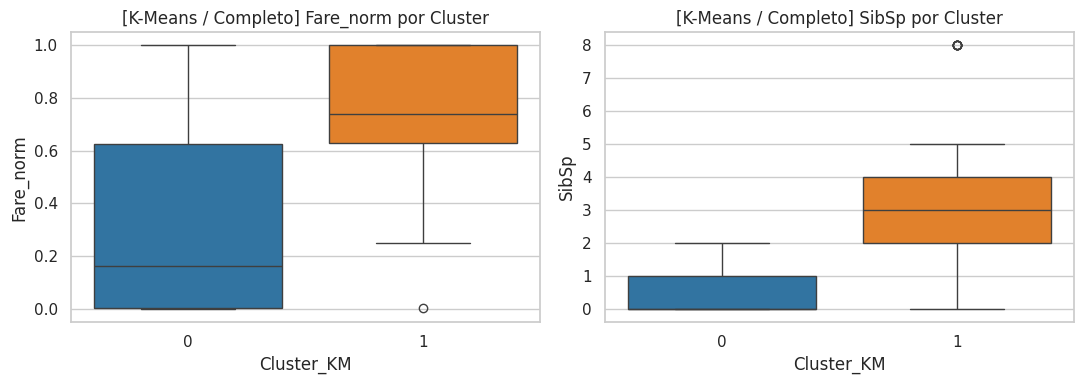

=== Validação a posteriori com Survived — K-Means / Completo ===


Survived,0,1,Total
Cluster,,,
0,498,324,822
1,51,18,69
Total,549,342,891



Taxa de sobrevivência por cluster:


,Taxa de Sobrevivência
Cluster,
0,0.394
1,0.261


(Survived    0    1  Total
 Cluster                  
 0         498  324    822
 1          51   18     69
 Total     549  342    891,
 Cluster
 0    0.394161
 1    0.260870
 Name: Taxa de Sobrevivência, dtype: float64)

In [ ]:
perfil_cluster(
    df_c_analise, 'Cluster_KM',
    num_cols=['SibSp', 'Parch', 'Fare_norm'],
    cat_cols=['Sex', 'Embarked', 'Pclass', 'Age_cut', 'Name']
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df_c_analise, x='Cluster_KM', y='Fare_norm', ax=axes[0], palette='tab10')
axes[0].set_title('[K-Means / Completo] Fare_norm por Cluster')
sns.boxplot(data=df_c_analise, x='Cluster_KM', y='SibSp', ax=axes[1], palette='tab10')
axes[1].set_title('[K-Means / Completo] SibSp por Cluster')
plt.tight_layout()
plt.show()

validar_com_survived(labels_km_c, y_survived, titulo='K-Means / Completo')

## 3.3 K-Prototypes — pré-processamento completo

### 3.3.1 Escolha de k

> **Nota sobre o BIC**: a aproximação de BIC implementada (`bic_kmeans`) assume distância euclidiana/gaussiana e não é diretamente aplicável ao K-Prototypes, que mistura distância euclidiana (numéricas) com distância de Hamming (categóricas) via o parâmetro `gamma`. Por isso, para o K-Prototypes usamos o **Custo** (equivalente à inércia) no lugar do BIC, combinado com Silhouette, Calinski-Harabasz e Davies-Bouldin — mantendo 4 métricas na votação.

In [ ]:
# K-Prototypes usa custo (equivalente à inércia do K-Means)
# Silhouette exige matriz numérica; usamos a parte numérica para o cálculo
X_c_kp_num = X_c_kp[:, [i for i in range(X_c_kp.shape[1]) if i not in cat_idx_c]].astype(float)

k_range = range(2, 11)
resultados_kp_c = []

for k in k_range:
    kp = KPrototypes(n_clusters=k, init='Cao', random_state=42, n_init=3, verbose=0)
    labels_kp = kp.fit_predict(X_c_kp, categorical=cat_idx_c)
    sil  = silhouette_score(X_c_kp_num, labels_kp) if len(np.unique(labels_kp)) > 1 else -1
    ch   = calinski_harabasz_score(X_c_kp_num, labels_kp) if len(np.unique(labels_kp)) > 1 else 0
    db   = davies_bouldin_score(X_c_kp_num, labels_kp) if len(np.unique(labels_kp)) > 1 else 99
    resultados_kp_c.append({
        'k': k, 'Custo (Elbow)': kp.cost_, 'Silhouette': sil,
        'Calinski-Harabasz': ch, 'Davies-Bouldin': db
    })
    print(f'k={k} | Custo: {kp.cost_:.2f} | Silhouette: {sil:.4f} | CH: {ch:.2f} | DB: {db:.4f}')

df_met_kp_c = pd.DataFrame(resultados_kp_c).set_index('k')
display(df_met_kp_c.round(4))

k=2 | Custo: 260.35 | Silhouette: 0.6544 | CH: 2123.65 | DB: 0.5573
k=3 | Custo: 225.12 | Silhouette: 0.3465 | CH: 980.40 | DB: 1.4856
k=4 | Custo: 202.16 | Silhouette: 0.1688 | CH: 713.75 | DB: 5.0150
k=5 | Custo: 186.76 | Silhouette: 0.1404 | CH: 751.16 | DB: 2.7571
k=6 | Custo: 170.58 | Silhouette: 0.1417 | CH: 640.11 | DB: 2.3492
k=7 | Custo: 165.02 | Silhouette: 0.0942 | CH: 551.29 | DB: 3.5669
k=8 | Custo: 155.08 | Silhouette: 0.1031 | CH: 468.83 | DB: 2.8040
k=9 | Custo: 158.50 | Silhouette: -0.3161 | CH: 421.58 | DB: 4.9317
k=10 | Custo: 150.59 | Silhouette: 0.0553 | CH: 424.60 | DB: 3.7553


,Custo (Elbow),Silhouette,Calinski-Harabasz,Davies-Bouldin
k,,,,
2,260.3477,0.6544,2123.6479,0.5573
3,225.1245,0.3465,980.3986,1.4856
4,202.1557,0.1688,713.7484,5.0150
5,186.7612,0.1404,751.1605,2.7571
6,170.5811,0.1417,640.1127,2.3492
7,165.0235,0.0942,551.2937,3.5669
8,155.0809,0.1031,468.8286,2.8040
9,158.4993,-0.3161,421.5775,4.9317
10,150.5930,0.0553,424.5962,3.7553


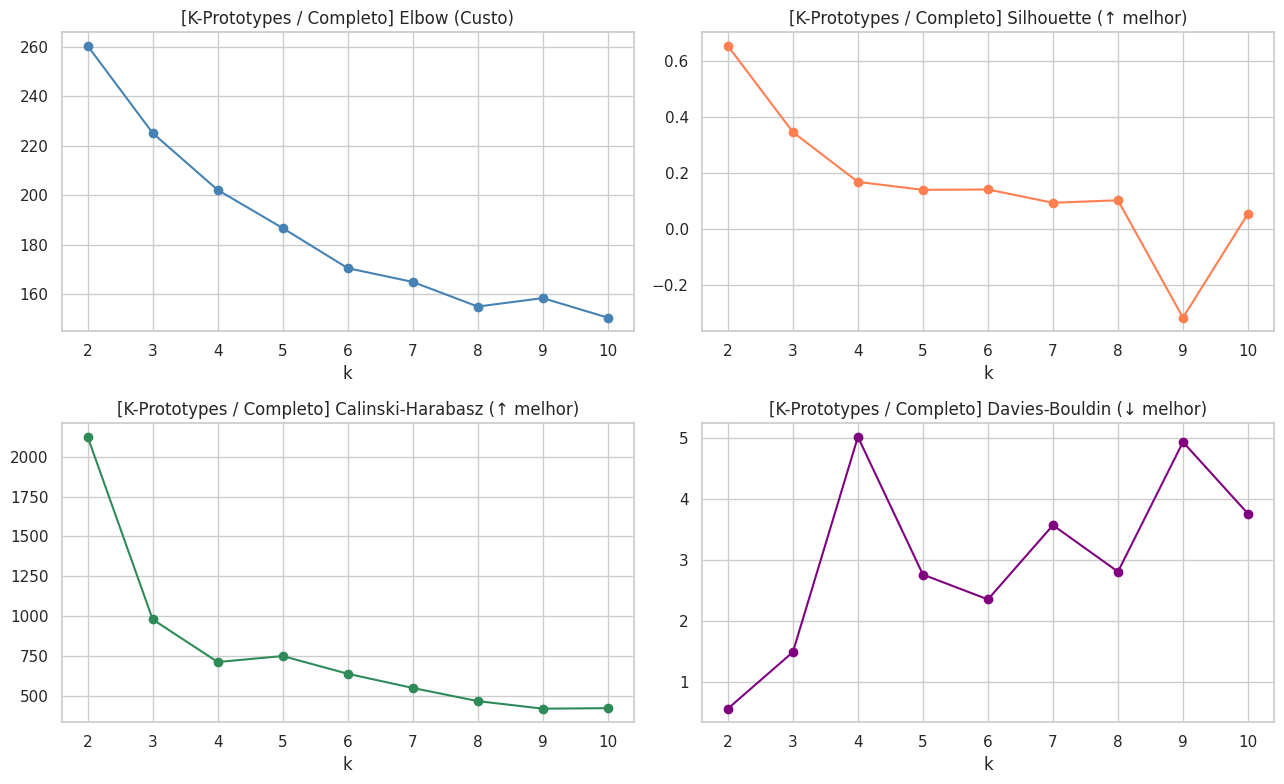

Melhor k por métrica (K-Prototypes / Pré-processamento Completo):
  Elbow (Custo)         : k = 9
  Silhouette            : k = 2
  Calinski-Harabasz     : k = 2
  Davies-Bouldin        : k = 2

→ k mais votado: 2


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

axes[0].plot(df_met_kp_c.index, df_met_kp_c['Custo (Elbow)'], marker='o', color='steelblue')
axes[0].set_title('[K-Prototypes / Completo] Elbow (Custo)')
axes[0].set_xlabel('k')

axes[1].plot(df_met_kp_c.index, df_met_kp_c['Silhouette'], marker='o', color='coral')
axes[1].set_title('[K-Prototypes / Completo] Silhouette (↑ melhor)')
axes[1].set_xlabel('k')

axes[2].plot(df_met_kp_c.index, df_met_kp_c['Calinski-Harabasz'], marker='o', color='seagreen')
axes[2].set_title('[K-Prototypes / Completo] Calinski-Harabasz (↑ melhor)')
axes[2].set_xlabel('k')

axes[3].plot(df_met_kp_c.index, df_met_kp_c['Davies-Bouldin'], marker='o', color='purple')
axes[3].set_title('[K-Prototypes / Completo] Davies-Bouldin (↓ melhor)')
axes[3].set_xlabel('k')

plt.tight_layout()
plt.show()

# Votação
votos_kp_c = {
    'Elbow (Custo)'     : df_met_kp_c['Custo (Elbow)'].diff().diff().abs().idxmax(),
    'Silhouette'        : df_met_kp_c['Silhouette'].idxmax(),
    'Calinski-Harabasz' : df_met_kp_c['Calinski-Harabasz'].idxmax(),
    'Davies-Bouldin'    : df_met_kp_c['Davies-Bouldin'].idxmin(),
}
print('Melhor k por métrica (K-Prototypes / Pré-processamento Completo):')
from collections import Counter
for met, k in votos_kp_c.items():
    print(f'  {met:22s}: k = {k}')
K_KP_C = Counter(votos_kp_c.values()).most_common(1)[0][0]
print(f'\n→ k mais votado: {K_KP_C}')

### 3.3.2 Treinamento com o k escolhido

In [ ]:
kp_c = KPrototypes(n_clusters=K_KP_C, init='Cao', random_state=42, n_init=5, verbose=0)
labels_kp_c = kp_c.fit_predict(X_c_kp, categorical=cat_idx_c)

print(f'K-Prototypes [Pré-processamento Completo] — k={K_KP_C}')
print('Distribuição dos clusters:')
print(pd.Series(labels_kp_c).value_counts().sort_index())

print('\nMétricas (parte numérica):')
print(f'  Silhouette        : {silhouette_score(X_c_kp_num, labels_kp_c):.4f}')
print(f'  Calinski-Harabasz : {calinski_harabasz_score(X_c_kp_num, labels_kp_c):.4f}')
print(f'  Davies-Bouldin    : {davies_bouldin_score(X_c_kp_num, labels_kp_c):.4f}')

print('\nDistâncias:')
intra_kp_c, inter_kp_c = distancias_intra_inter(X_c_kp_num, labels_kp_c)

K-Prototypes [Pré-processamento Completo] — k=2
Distribuição dos clusters:
0    551
1    340
Name: count, dtype: int64

Métricas (parte numérica):
  Silhouette        : 0.6544
  Calinski-Harabasz : 2123.6479
  Davies-Bouldin    : 0.5573

Distâncias:
  Distância Intra-cluster (média): 0.2122
  Distância Inter-cluster (média entre centróides): 0.7614


### 3.3.3 Árvore de rotulação e extração de regras


=== Regras da Árvore — K-Prototypes / Pré-processamento Completo ===
|--- Fare_norm <= 0.53
|   |--- Fare_norm <= 0.47
|   |   |--- class: 0
|   |--- Fare_norm >  0.47
|   |   |--- Pclass_3 <= 0.50
|   |   |   |--- class: 1
|   |   |--- Pclass_3 >  0.50
|   |   |   |--- class: 0
|--- Fare_norm >  0.53
|   |--- class: 1



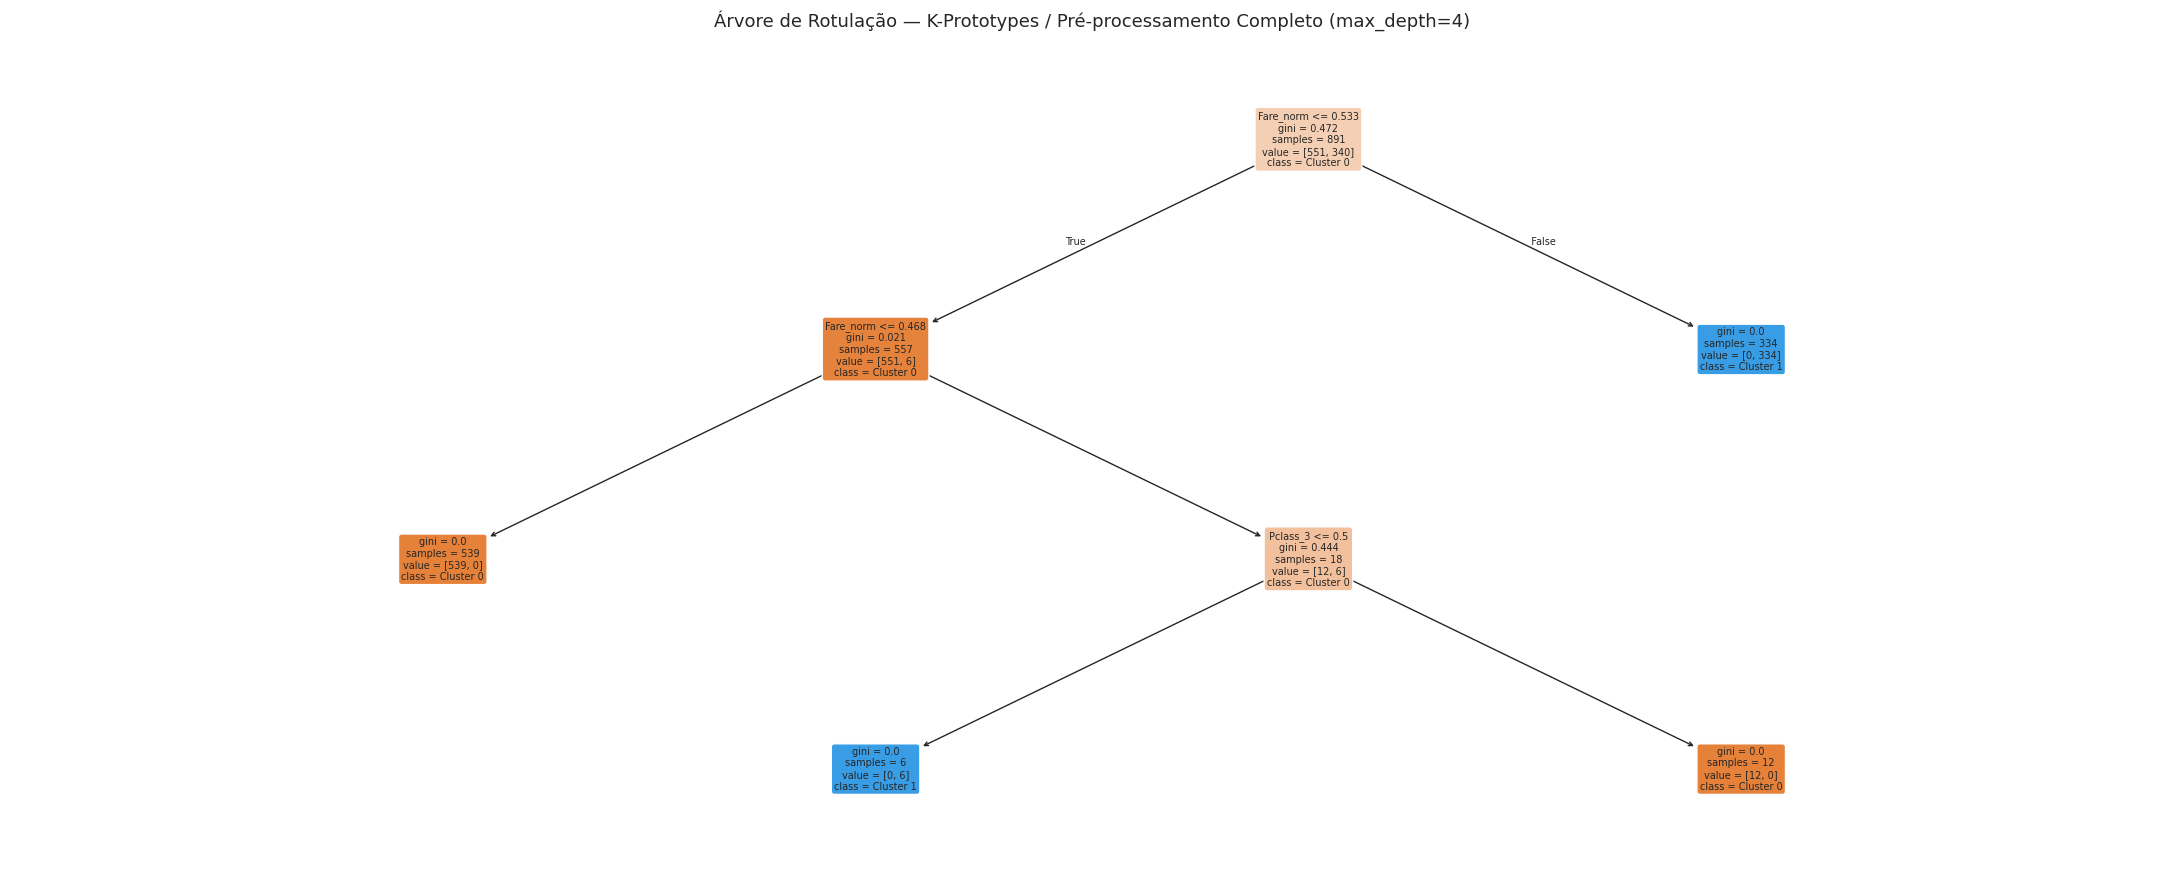

In [ ]:
dt_kp_c = arvore_de_rotulacao(
    X_c, labels_kp_c, feature_names_c,
    titulo='K-Prototypes / Pré-processamento Completo'
)

### 3.3.4 Análise dos clusters

In [ ]:
df_c_analise['Cluster_KP'] = labels_kp_c
print('Perfil médio por cluster (K-Prototypes / Pré-processamento Completo):')
display(df_c_analise.groupby('Cluster_KP').mean(numeric_only=True).round(2))

Perfil médio por cluster (K-Prototypes / Pré-processamento Completo):


,SibSp,Parch,Fare_norm,Cluster_KM
Cluster_KP,,,,
0,0.24,0.17,0.09,0.02
1,0.98,0.72,0.84,0.17



--- Cluster 0 (551 pontos, 61.8% da base) ---
  Variáveis numéricas mais distintivas (|z-score| da média geral):
    Fare_norm      : média no cluster = 0.09 | média geral = 0.38 | z = 0.72
    Parch          : média no cluster = 0.17 | média geral = 0.38 | z = 0.26
    SibSp          : média no cluster = 0.24 | média geral = 0.52 | z = 0.26
  Categorias predominantes:
    Sex            : male (71.1% do cluster)
    Embarked       : S (74.0% do cluster)
    Pclass         : 3 (78.9% do cluster)
    Age_cut        : 25-40 (48.5% do cluster)
    Name           : Mr. (67.3% do cluster)

--- Cluster 1 (340 pontos, 38.2% da base) ---
  Variáveis numéricas mais distintivas (|z-score| da média geral):
    Fare_norm      : média no cluster = 0.84 | média geral = 0.38 | z = 1.17
    Parch          : média no cluster = 0.72 | média geral = 0.38 | z = 0.42
    SibSp          : média no cluster = 0.98 | média geral = 0.52 | z = 0.41
  Categorias predominantes:
    Sex            : male (54.4% do

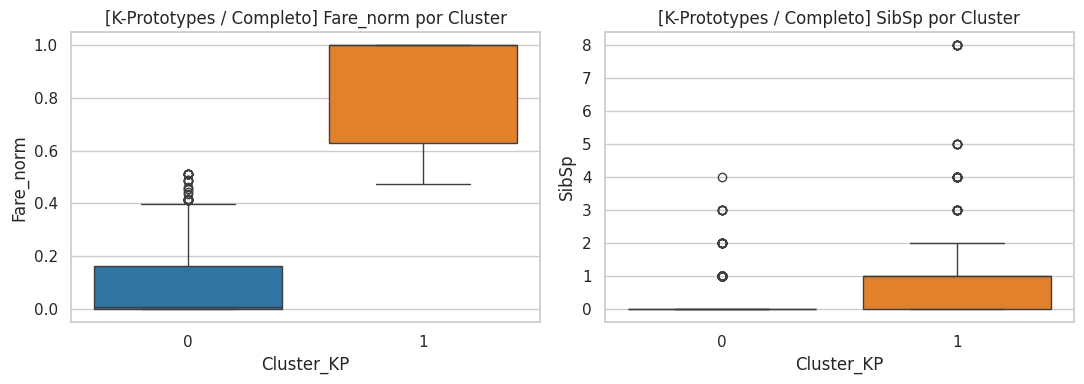

=== Validação a posteriori com Survived — K-Prototypes / Completo ===


Survived,0,1,Total
Cluster,,,
0,396,155,551
1,153,187,340
Total,549,342,891



Taxa de sobrevivência por cluster:


,Taxa de Sobrevivência
Cluster,
0,0.281
1,0.550


(Survived    0    1  Total
 Cluster                  
 0         396  155    551
 1         153  187    340
 Total     549  342    891,
 Cluster
 0    0.281307
 1    0.550000
 Name: Taxa de Sobrevivência, dtype: float64)

In [ ]:
perfil_cluster(
    df_c_analise, 'Cluster_KP',
    num_cols=['SibSp', 'Parch', 'Fare_norm'],
    cat_cols=['Sex', 'Embarked', 'Pclass', 'Age_cut', 'Name']
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df_c_analise, x='Cluster_KP', y='Fare_norm', ax=axes[0], palette='tab10')
axes[0].set_title('[K-Prototypes / Completo] Fare_norm por Cluster')
sns.boxplot(data=df_c_analise, x='Cluster_KP', y='SibSp', ax=axes[1], palette='tab10')
axes[1].set_title('[K-Prototypes / Completo] SibSp por Cluster')
plt.tight_layout()
plt.show()

validar_com_survived(labels_kp_c, y_survived, titulo='K-Prototypes / Completo')

## 3.4 DBSCAN — pré-processamento completo

### 3.4.1 Escolha de eps com curva k-dist

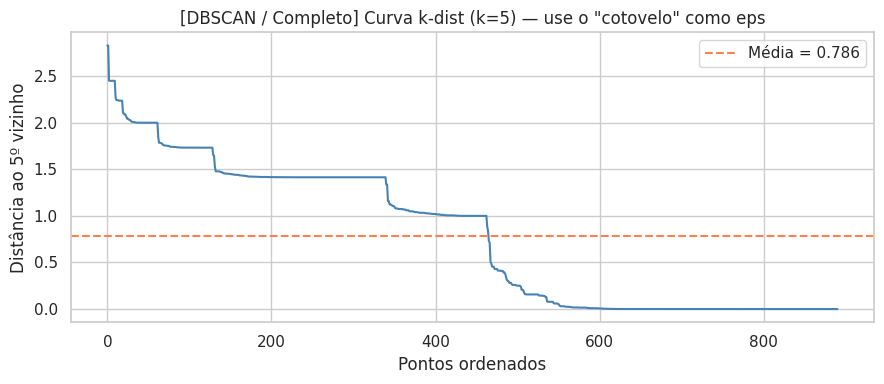

In [ ]:
# Curva de distância ao k-ésimo vizinho mais próximo (k = min_samples)
MIN_SAMPLES_C = 5
nbrs_c = NearestNeighbors(n_neighbors=MIN_SAMPLES_C).fit(X_c)
dists_c, _ = nbrs_c.kneighbors(X_c)
kth_dist_c  = np.sort(dists_c[:, -1])[::-1]

plt.figure(figsize=(9, 4))
plt.plot(kth_dist_c, color='steelblue')
plt.axhline(y=kth_dist_c.mean(), color='coral', linestyle='--', label=f'Média = {kth_dist_c.mean():.3f}')
plt.title(f'[DBSCAN / Completo] Curva k-dist (k={MIN_SAMPLES_C}) — use o "cotovelo" como eps')
plt.xlabel('Pontos ordenados')
plt.ylabel(f'Distância ao {MIN_SAMPLES_C}º vizinho')
plt.legend()
plt.tight_layout()
plt.show()

eps=0.10 | clusters=20 | ruído=531 | Silhouette=0.1552
eps=0.15 | clusters=21 | ruído=523 | Silhouette=0.1618
eps=0.20 | clusters=24 | ruído=501 | Silhouette=0.1855
eps=0.25 | clusters=24 | ruído=495 | Silhouette=0.1944
eps=0.30 | clusters=26 | ruído=478 | Silhouette=0.2189
eps=0.35 | clusters=26 | ruído=476 | Silhouette=0.2218
eps=0.40 | clusters=26 | ruído=472 | Silhouette=0.2275
eps=0.45 | clusters=27 | ruído=467 | Silhouette=0.2342
eps=0.50 | clusters=26 | ruído=466 | Silhouette=0.2243
eps=0.55 | clusters=26 | ruído=466 | Silhouette=0.2243
eps=0.60 | clusters=26 | ruído=464 | Silhouette=0.2261
eps=0.65 | clusters=26 | ruído=464 | Silhouette=0.2261
eps=0.70 | clusters=26 | ruído=464 | Silhouette=0.2261
eps=0.75 | clusters=26 | ruído=463 | Silhouette=0.2283
eps=0.80 | clusters=26 | ruído=463 | Silhouette=0.2283
eps=0.85 | clusters=26 | ruído=462 | Silhouette=0.2289
eps=0.90 | clusters=26 | ruído=462 | Silhouette=0.2289
eps=0.95 | clusters=26 | ruído=462 | Silhouette=0.2289
eps=1.00 |

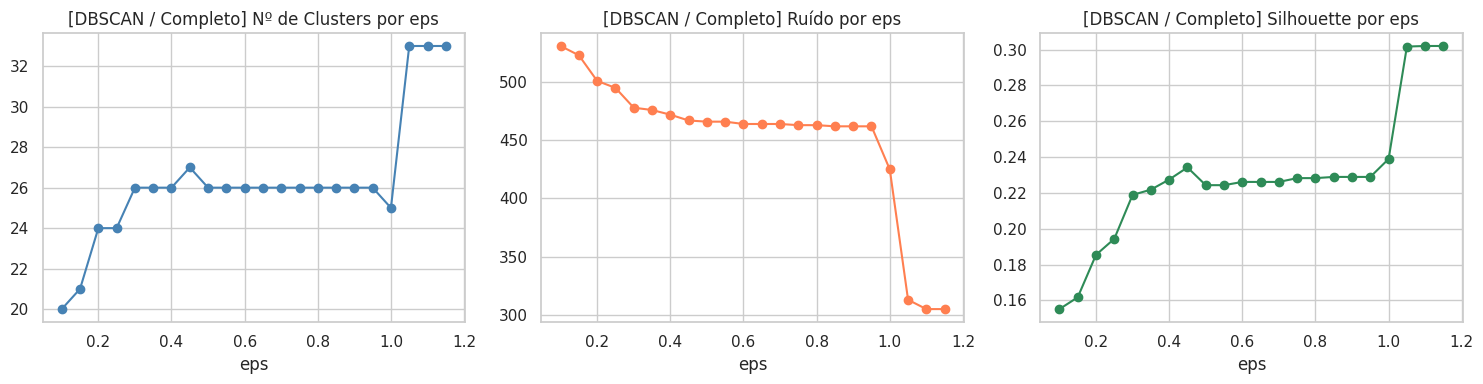

In [ ]:
# Varredura de eps para encontrar melhor Silhouette
eps_vals_c = np.arange(0.1, 1.2, 0.05)
resultados_dbscan_c = []

for eps in eps_vals_c:
    db = DBSCAN(eps=eps, min_samples=MIN_SAMPLES_C)
    lbs = db.fit_predict(X_c)
    n_clusters = len(set(lbs)) - (1 if -1 in lbs else 0)
    n_noise    = (lbs == -1).sum()
    if n_clusters > 1:
        sil = silhouette_score(X_c, lbs)
    else:
        sil = -1
    resultados_dbscan_c.append({
        'eps': round(eps, 2), 'n_clusters': n_clusters,
        'n_noise': n_noise, 'Silhouette': sil
    })
    print(f'eps={eps:.2f} | clusters={n_clusters} | ruído={n_noise} | Silhouette={sil:.4f}')

df_dbscan_c = pd.DataFrame(resultados_dbscan_c)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(df_dbscan_c['eps'], df_dbscan_c['n_clusters'], marker='o', color='steelblue')
axes[0].set_title('[DBSCAN / Completo] Nº de Clusters por eps')
axes[0].set_xlabel('eps')
axes[1].plot(df_dbscan_c['eps'], df_dbscan_c['n_noise'], marker='o', color='coral')
axes[1].set_title('[DBSCAN / Completo] Ruído por eps')
axes[1].set_xlabel('eps')
axes[2].plot(df_dbscan_c['eps'], df_dbscan_c['Silhouette'], marker='o', color='seagreen')
axes[2].set_title('[DBSCAN / Completo] Silhouette por eps')
axes[2].set_xlabel('eps')
plt.tight_layout()
plt.show()

### 3.4.2 Treinamento com eps escolhido

In [ ]:
# Ajuste EPS_C conforme o cotovelo da curva k-dist e os gráficos acima
EPS_C = df_dbscan_c.loc[df_dbscan_c['Silhouette'].idxmax(), 'eps']
print(f'eps selecionado automaticamente (melhor Silhouette): {EPS_C}')
# Para sobrescrever: EPS_C = 0.5

db_c = DBSCAN(eps=EPS_C, min_samples=MIN_SAMPLES_C)
labels_db_c = db_c.fit_predict(X_c)

n_clusters_db_c = len(set(labels_db_c)) - (1 if -1 in labels_db_c else 0)
n_noise_db_c    = (labels_db_c == -1).sum()

print(f'\nDBSCAN [Pré-processamento Completo] — eps={EPS_C} | min_samples={MIN_SAMPLES_C}')
print(f'Clusters encontrados : {n_clusters_db_c}')
print(f'Pontos de ruído      : {n_noise_db_c} ({n_noise_db_c/len(labels_db_c):.1%})')
print('Distribuição:', pd.Series(labels_db_c).value_counts().sort_index().to_dict())

if n_clusters_db_c > 1:
    mask_db_c = labels_db_c >= 0
    print(f'\nMétricas (excluindo ruído):')
    print(f'  Silhouette        : {silhouette_score(X_c[mask_db_c], labels_db_c[mask_db_c]):.4f}')
    print(f'  Calinski-Harabasz : {calinski_harabasz_score(X_c[mask_db_c], labels_db_c[mask_db_c]):.4f}')
    print(f'  Davies-Bouldin    : {davies_bouldin_score(X_c[mask_db_c], labels_db_c[mask_db_c]):.4f}')
    print('\nDistâncias:')
    intra_db_c, inter_db_c = distancias_intra_inter(X_c, labels_db_c)

eps selecionado automaticamente (melhor Silhouette): 1.1

DBSCAN [Pré-processamento Completo] — eps=1.1 | min_samples=5
Clusters encontrados : 33
Pontos de ruído      : 305 (34.2%)
Distribuição: {-1: 305, 0: 66, 1: 8, 2: 120, 3: 28, 4: 10, 5: 9, 6: 9, 7: 39, 8: 12, 9: 6, 10: 28, 11: 24, 12: 16, 13: 5, 14: 12, 15: 15, 16: 13, 17: 11, 18: 10, 19: 6, 20: 6, 21: 12, 22: 17, 23: 8, 24: 25, 25: 17, 26: 20, 27: 6, 28: 7, 29: 5, 30: 6, 31: 5, 32: 5}

Métricas (excluindo ruído):
  Silhouette        : 0.6611
  Calinski-Harabasz : 147.5787
  Davies-Bouldin    : 0.7695

Distâncias:
  Distância Intra-cluster (média): 0.5046
  Distância Inter-cluster (média entre centróides): 2.7979


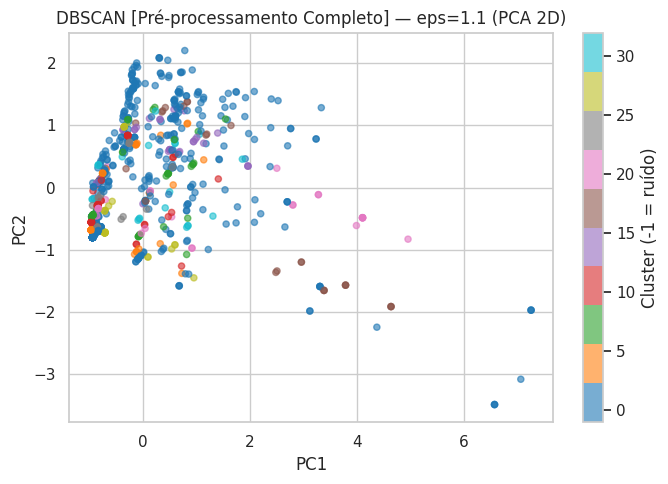

In [ ]:
# Visualização
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_c_2d[:, 0], X_c_2d[:, 1],
                      c=labels_db_c, cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Cluster (-1 = ruído)')
plt.title(f'DBSCAN [Pré-processamento Completo] — eps={EPS_C} (PCA 2D)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout()
plt.show()

### 3.4.3 Árvore de rotulação e extração de regras


=== Regras da Árvore — DBSCAN / Pré-processamento Completo ===
|--- Age_cut_25-40 <= 0.50
|   |--- Age_cut_18-25 <= 0.50
|   |   |--- Age_cut_0-18 <= 0.50
|   |   |   |--- Pclass_3 <= 0.50
|   |   |   |   |--- class: 12
|   |   |   |--- Pclass_3 >  0.50
|   |   |   |   |--- class: 24
|   |   |--- Age_cut_0-18 >  0.50
|   |   |   |--- Name_Mr. <= 0.50
|   |   |   |   |--- class: 16
|   |   |   |--- Name_Mr. >  0.50
|   |   |   |   |--- class: 26
|   |--- Age_cut_18-25 >  0.50
|   |   |--- Sex_female <= 0.50
|   |   |   |--- Pclass_3 <= 0.50
|   |   |   |   |--- class: 22
|   |   |   |--- Pclass_3 >  0.50
|   |   |   |   |--- class: 0
|   |   |--- Sex_female >  0.50
|   |   |   |--- Embarked_Q <= 0.50
|   |   |   |   |--- class: 25
|   |   |   |--- Embarked_Q >  0.50
|   |   |   |   |--- class: 11
|--- Age_cut_25-40 >  0.50
|   |--- Pclass_3 <= 0.50
|   |   |--- Name_Mrs. <= 0.50
|   |   |   |--- Pclass_2 <= 0.50
|   |   |   |   |--- class: 17
|   |   |   |--- Pclass_2 >  0.50
|   |   |

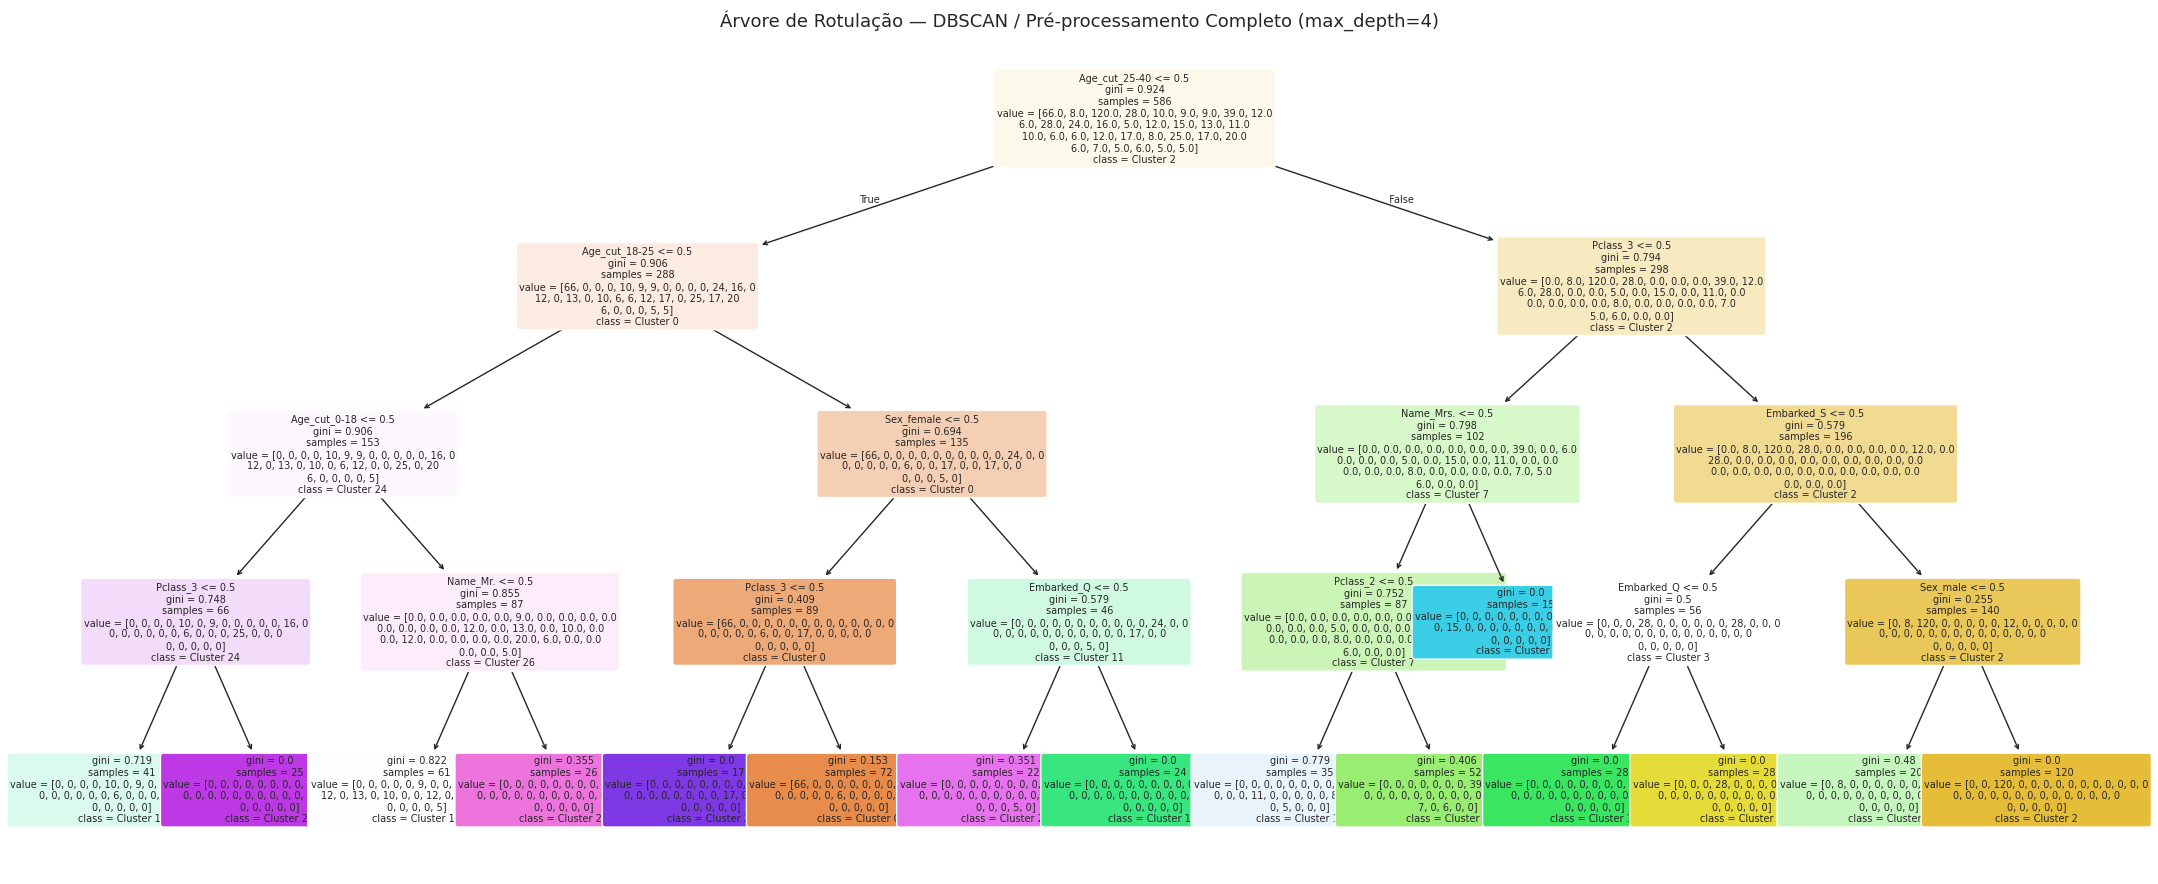

In [ ]:
if n_clusters_db_c > 1:
    dt_db_c = arvore_de_rotulacao(
        X_c, labels_db_c, feature_names_c,
        titulo='DBSCAN / Pré-processamento Completo'
    )
else:
    print('DBSCAN encontrou apenas 1 cluster — ajuste eps para gerar a árvore.')

### 3.4.4 Análise dos clusters

In [ ]:
df_c_analise['Cluster_DB'] = labels_db_c
print('Perfil médio por cluster (DBSCAN / Pré-processamento Completo, ruído incluído como -1):')
display(df_c_analise.groupby('Cluster_DB').mean(numeric_only=True).round(2))

Perfil médio por cluster (DBSCAN / Pré-processamento Completo, ruído incluído como -1):


,SibSp,Parch,Fare_norm,Cluster_KM,Cluster_KP
Cluster_DB,,,,,
-1,0.77,0.70,0.66,0.13,0.69
0,0.12,0.00,0.03,0.00,0.00
1,0.00,0.00,0.03,0.00,0.00
2,0.17,0.06,0.11,0.00,0.06
3,0.25,0.04,0.09,0.00,0.00
4,0.30,0.10,0.79,0.00,1.00
5,0.11,0.67,0.16,0.00,0.00
6,0.44,0.56,0.47,0.00,0.56
7,0.26,0.08,0.24,0.00,0.21


In [ ]:
if n_clusters_db_c > 1:
    perfil_cluster(
        df_c_analise[df_c_analise['Cluster_DB'] >= 0], 'Cluster_DB',
        num_cols=['SibSp', 'Parch', 'Fare_norm'],
        cat_cols=['Sex', 'Embarked', 'Pclass', 'Age_cut', 'Name']
    )
    validar_com_survived(labels_db_c, y_survived, titulo='DBSCAN / Completo')
else:
    print('DBSCAN encontrou apenas 1 cluster — sem sentido comparar perfis.')


--- Cluster 0 (66 pontos, 11.3% da base) ---
  Variáveis numéricas mais distintivas (|z-score| da média geral):
    Fare_norm      : média no cluster = 0.03 | média geral = 0.23 | z = 0.64
    Parch          : média no cluster = 0.00 | média geral = 0.21 | z = 0.40
    SibSp          : média no cluster = 0.12 | média geral = 0.39 | z = 0.31
  Categorias predominantes:
    Sex            : male (100.0% do cluster)
    Embarked       : S (100.0% do cluster)
    Pclass         : 3 (100.0% do cluster)
    Age_cut        : 18-25 (100.0% do cluster)
    Name           : Mr. (100.0% do cluster)

--- Cluster 1 (8 pontos, 1.4% da base) ---
  Variáveis numéricas mais distintivas (|z-score| da média geral):
    Fare_norm      : média no cluster = 0.03 | média geral = 0.23 | z = 0.65
    SibSp          : média no cluster = 0.00 | média geral = 0.39 | z = 0.45
    Parch          : média no cluster = 0.00 | média geral = 0.21 | z = 0.40
  Categorias predominantes:
    Sex            : female (100.0

Survived,0,1,Total
Cluster,,,
-1,118,187,305
0,60,6,66
1,4,4,8
2,104,16,120
3,25,3,28
4,7,3,10
5,3,6,9
6,1,8,9
7,36,3,39



Taxa de sobrevivência por cluster:


,Taxa de Sobrevivência
Cluster,
-1,0.613
0,0.091
1,0.500
2,0.133
3,0.107
4,0.300
5,0.667
6,0.889
7,0.077


## 3.5 Comparação — Baseline vs. Pré-processamento Completo

In [ ]:
comparacao = pd.DataFrame({
    'K-Means [Sem Tratamento]'     : [silhouette_score(X_s, labels_km_s), calinski_harabasz_score(X_s, labels_km_s), davies_bouldin_score(X_s, labels_km_s)],
    'K-Means [Completo]'           : [silhouette_score(X_c, labels_km_c), calinski_harabasz_score(X_c, labels_km_c), davies_bouldin_score(X_c, labels_km_c)],
    'K-Prototypes [Sem Tratamento]': [silhouette_score(X_s_kp_num, labels_kp_s), calinski_harabasz_score(X_s_kp_num, labels_kp_s), davies_bouldin_score(X_s_kp_num, labels_kp_s)],
    'K-Prototypes [Completo]'      : [silhouette_score(X_c_kp_num, labels_kp_c), calinski_harabasz_score(X_c_kp_num, labels_kp_c), davies_bouldin_score(X_c_kp_num, labels_kp_c)],
}, index=['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin']).round(4)

if n_clusters_db_s > 1:
    comparacao['DBSCAN [Sem Tratamento]'] = [
        silhouette_score(X_s[mask_db_s], labels_db_s[mask_db_s]),
        calinski_harabasz_score(X_s[mask_db_s], labels_db_s[mask_db_s]),
        davies_bouldin_score(X_s[mask_db_s], labels_db_s[mask_db_s]),
    ]
if n_clusters_db_c > 1:
    comparacao['DBSCAN [Completo]'] = [
        silhouette_score(X_c[mask_db_c], labels_db_c[mask_db_c]),
        calinski_harabasz_score(X_c[mask_db_c], labels_db_c[mask_db_c]),
        davies_bouldin_score(X_c[mask_db_c], labels_db_c[mask_db_c]),
    ]

display(comparacao.T)

,Silhouette,Calinski-Harabasz,Davies-Bouldin
K-Means [Sem Tratamento],0.591600,1124.173500,0.593900
K-Means [Completo],0.430700,210.012100,1.208500
K-Prototypes [Sem Tratamento],0.565600,1381.885600,0.701100
K-Prototypes [Completo],0.654400,2123.647900,0.557300
DBSCAN [Sem Tratamento],0.629150,716.985929,0.615918
DBSCAN [Completo],0.661131,147.578724,0.769477


---
# **PARTE 4 — Comparação entre os Algoritmos e Conclusões**

Até aqui comparamos cada algoritmo **contra si mesmo** (baseline vs. pré-processamento completo). Falta comparar os algoritmos **entre si**, dentro de cada versão da base, e consolidar o que os clusters revelam sobre os passageiros do Titanic.

## 4.1 Concordância entre algoritmos (ARI / NMI)

O **Adjusted Rand Index** e a **Normalized Mutual Information** medem o quanto duas partições diferentes concordam sobre quais pontos pertencem ao mesmo grupo — independente de como os clusters foram numerados. Comparamos os rótulos de K-Means, K-Prototypes e DBSCAN dentro de cada versão da base.

In [ ]:
# Nota: só faz sentido comparar clusterizações com o mesmo número de pontos;
# no DBSCAN os pontos de ruído (-1) são mantidos aqui como um 'cluster' a mais
# para preservar o tamanho do vetor de rótulos.

print('### Base SEM tratamento (Parte 1) ###')
labels_sem_tratamento = {
    'K-Means'      : labels_km_s,
    'K-Prototypes' : labels_kp_s,
    'DBSCAN'       : labels_db_s,
}
ari_s, nmi_s = comparar_algoritmos(labels_sem_tratamento)

### Base SEM tratamento (Parte 1) ###
Adjusted Rand Index (ARI) entre algoritmos:


,K-Means,K-Prototypes,DBSCAN
K-Means,1.000,0.320,0.598
K-Prototypes,0.320,1.000,0.022
DBSCAN,0.598,0.022,1.000



Normalized Mutual Information (NMI) entre algoritmos:


,K-Means,K-Prototypes,DBSCAN
K-Means,1.000,0.458,0.819
K-Prototypes,0.458,1.000,0.051
DBSCAN,0.819,0.051,1.000


In [ ]:
print('### Base com PRÉ-PROCESSAMENTO COMPLETO (Parte 2/3) ###')
labels_completo = {
    'K-Means'      : labels_km_c,
    'K-Prototypes' : labels_kp_c,
    'DBSCAN'       : labels_db_c,
}
ari_c, nmi_c = comparar_algoritmos(labels_completo)

### Base com PRÉ-PROCESSAMENTO COMPLETO (Parte 2/3) ###
Adjusted Rand Index (ARI) entre algoritmos:


,K-Means,K-Prototypes,DBSCAN
K-Means,1.000,0.083,-0.015
K-Prototypes,0.083,1.000,0.065
DBSCAN,-0.015,0.065,1.000



Normalized Mutual Information (NMI) entre algoritmos:


,K-Means,K-Prototypes,DBSCAN
K-Means,1.000,0.086,0.088
K-Prototypes,0.086,1.000,0.197
DBSCAN,0.088,0.197,1.000


### 4.1.1 Tabelas de contingência (crosstab)

Além do índice resumido, vale olhar a tabela completa de cruzamento entre pares de algoritmos para entender *como* eles discordam (ex: um algoritmo junta dois clusters que o outro separa).

In [ ]:
print('Sem Tratamento — K-Means x K-Prototypes:')
display(pd.crosstab(labels_km_s, labels_kp_s, rownames=['K-Means'], colnames=['K-Prototypes']))

print('\nSem Tratamento — K-Means x DBSCAN:')
display(pd.crosstab(labels_km_s, labels_db_s, rownames=['K-Means'], colnames=['DBSCAN']))

print('\nCompleto — K-Means x K-Prototypes:')
display(pd.crosstab(labels_km_c, labels_kp_c, rownames=['K-Means'], colnames=['K-Prototypes']))

print('\nCompleto — K-Means x DBSCAN:')
display(pd.crosstab(labels_km_c, labels_db_c, rownames=['K-Means'], colnames=['DBSCAN']))

Sem Tratamento — K-Means x K-Prototypes:


K-Prototypes,0,1
K-Means,,
0,265,0
1,88,0
2,0,43
3,33,3
4,0,117
5,0,42
6,0,176
7,39,2
8,23,7



Sem Tratamento — K-Means x DBSCAN:


DBSCAN,0,1,2,3,4,5
K-Means,,,,,,
0,265,0,0,0,0,0
1,0,0,88,0,0,0
2,0,43,0,0,0,0
3,0,0,0,0,36,0
4,0,0,117,0,0,0
5,0,0,0,0,0,42
6,176,0,0,0,0,0
7,0,0,0,41,0,0
8,0,30,0,0,0,0



Completo — K-Means x K-Prototypes:


K-Prototypes,0,1
K-Means,,
0,541,281
1,10,59



Completo — K-Means x DBSCAN:


DBSCAN,-1,0,1,2,3,4,5,6,7,8,...,23,24,25,26,27,28,29,30,31,32
K-Means,,,,,,,,,,,,,,,,,,,,,
0,265,66,8,120,28,10,9,9,39,12,...,8,25,17,20,6,7,5,6,4,5
1,40,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


## 4.2 Síntese das métricas internas

Reunindo Silhouette, Calinski-Harabasz e Davies-Bouldin de todas as 6 combinações (3 algoritmos × 2 versões da base) em uma única tabela para facilitar a comparação final.

In [ ]:
sintese = pd.DataFrame({
    'Algoritmo'  : ['K-Means', 'K-Prototypes', 'DBSCAN', 'K-Means', 'K-Prototypes', 'DBSCAN'],
    'Base'       : ['Sem Tratamento']*3 + ['Completo']*3,
    'k / clusters': [K_KM_S, K_KP_S, n_clusters_db_s, K_KM_C, K_KP_C, n_clusters_db_c],
    'Silhouette' : [
        silhouette_score(X_s, labels_km_s),
        silhouette_score(X_s_kp_num, labels_kp_s),
        silhouette_score(X_s[mask_db_s], labels_db_s[mask_db_s]) if n_clusters_db_s > 1 else np.nan,
        silhouette_score(X_c, labels_km_c),
        silhouette_score(X_c_kp_num, labels_kp_c),
        silhouette_score(X_c[mask_db_c], labels_db_c[mask_db_c]) if n_clusters_db_c > 1 else np.nan,
    ],
    'Calinski-Harabasz' : [
        calinski_harabasz_score(X_s, labels_km_s),
        calinski_harabasz_score(X_s_kp_num, labels_kp_s),
        calinski_harabasz_score(X_s[mask_db_s], labels_db_s[mask_db_s]) if n_clusters_db_s > 1 else np.nan,
        calinski_harabasz_score(X_c, labels_km_c),
        calinski_harabasz_score(X_c_kp_num, labels_kp_c),
        calinski_harabasz_score(X_c[mask_db_c], labels_db_c[mask_db_c]) if n_clusters_db_c > 1 else np.nan,
    ],
    'Davies-Bouldin' : [
        davies_bouldin_score(X_s, labels_km_s),
        davies_bouldin_score(X_s_kp_num, labels_kp_s),
        davies_bouldin_score(X_s[mask_db_s], labels_db_s[mask_db_s]) if n_clusters_db_s > 1 else np.nan,
        davies_bouldin_score(X_c, labels_km_c),
        davies_bouldin_score(X_c_kp_num, labels_kp_c),
        davies_bouldin_score(X_c[mask_db_c], labels_db_c[mask_db_c]) if n_clusters_db_c > 1 else np.nan,
    ],
}).round(4)

display(sintese)

,Algoritmo,Base,k / clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,K-Means,Sem Tratamento,10,0.5916,1124.1735,0.5939
1,K-Prototypes,Sem Tratamento,2,0.5656,1381.8856,0.7011
2,DBSCAN,Sem Tratamento,6,0.6291,716.9859,0.6159
3,K-Means,Completo,2,0.4307,210.0121,1.2085
4,K-Prototypes,Completo,2,0.6544,2123.6479,0.5573
5,DBSCAN,Completo,33,0.6611,147.5787,0.7695


## 4.3 Conclusões

**1. Qual algoritmo formou clusters mais bem definidos?**<br>
O K-Prototypes na base com pré-processamento completo é o mais consistente: melhor Silhouette (0.6544), melhor Calinski-Harabasz (2123.65) e melhor Davies-Bouldin (0.5573) simultaneamente — as três métricas concordam. O DBSCAN completo teve Silhouette ligeiramente maior (0.6611), mas isso é enganoso: ele criou 33 clusters e descartou 34,2% dos pontos como ruído (305 de 891), muitos clusters com apenas 5-10 pontos. Silhouette alto em grupos minúsculos e superajustados não indica clusters úteis. O K-Prototypes vence por ser bem definido *e* interpretável com poucos clusters.

**2. O pré-processamento completo melhorou a formação dos clusters?**<br>
Não de forma uniforme. O K-Prototypes melhorou em tudo (Silhouette 0.566→0.654, Davies-Bouldin 0.701→0.557). Já o K-Means piorou bastante (Silhouette 0.592→0.431, Davies-Bouldin 0.594→1.209, Calinski-Harabasz caiu de 1124 para 210). O DBSCAN teve resultado ambíguo: Silhouette subiu (0.629→0.661), mas Calinski-Harabasz despencou (717→148) e o número de clusters explodiu de 6 para 33, com 34% de ruído.

Causa provável: no pré-processamento completo, `SibSp` e `Parch` continuam em escala bruta (0-8), enquanto `Fare_norm` e as dummies estão em 0-1. Isso faz essas duas variáveis dominarem a distância euclidiana — a árvore do K-Means completo confirma que ele passou a dividir os passageiros quase inteiramente por `SibSp`/`Parch` (tamanho da família), e não mais por classe/sexo como antes. Vale considerar normalizar `SibSp`/`Parch` também no pré-processamento.

**3. Os três algoritmos concordam sobre os grupos?**<br>
Não, e a concordância piora na base completa. Na base sem tratamento, K-Means e DBSCAN concordam razoavelmente (ARI 0.598, NMI 0.819) — ambos separam por sexo/embarque/classe. O K-Prototypes diverge de ambos (ARI ≤ 0.32) porque só enxerga classe social (Pclass). Na base completa, todos os pares têm ARI próximo de zero (entre -0.015 e 0.083) — nenhum algoritmo concorda com outro. Cada um capta uma estrutura diferente: K-Means → tamanho de família, K-Prototypes → tarifa/classe, DBSCAN → nichos demográficos fragmentados.

**4. O que caracteriza cada cluster?**<br>
Os padrões mais nítidos e estáveis vêm do K-Prototypes nas duas versões: sem tratamento (k=2), Cluster 0 = 3ª classe/tarifa baixa (13.68) vs Cluster 1 = classe média-alta/tarifa alta (54.95); completo (k=2), a árvore confirma `Fare_norm` e `Pclass_3` como variáveis decisivas — Cluster 0 = 78,9% 3ª classe, tarifa normalizada 0.09; Cluster 1 = 61,8% 1ª classe, tarifa normalizada 0.84.

No K-Means sem tratamento (k=10), a árvore mostra que Pclass, Sex e Embarked — nessa ordem — são as variáveis que mais separam os clusters, gerando segmentos como "mulheres 1ª classe embarcadas em Cherbourg" vs "homens 3ª classe embarcados em Southampton".

**5. Os clusters fazem sentido em relação à sobrevivência?**<br>
Sim, de forma marcante, especialmente nos clusters guiados por classe social e sexo — mesmo sem `Survived` ter sido usado no treino:

- K-Means sem tratamento: taxa de sobrevivência varia de 7,3% (homens, 3ª classe, Queenstown) a 97,7% (mulheres, 1ª classe, Cherbourg).
- K-Prototypes (as duas versões): o cluster de tarifa/classe alta sobrevive muito mais — 55,8% vs 24,2% (sem tratamento) e 55,0% vs 28,1% (completo).
- DBSCAN sem tratamento: 87,7% (mulheres, 1ª/2ª classe, Cherbourg) vs 7,3% (homens, 3ª classe, Queenstown).
- DBSCAN completo: oscila entre 0% e 100%, mas a maioria dos clusters tem menos de 15 pontos — variância alta demais para conclusões robustas. O próprio grupo de "ruído" (305 pontos não agrupados) teve 61,3% de sobrevivência, acima da média geral de 38,4%, possivelmente por reunir passageiros atípicos e mais abastados.

**Conclusão geral**: mesmo sem usar o rótulo, os clusters recuperam o padrão histórico conhecido do Titanic — classe social e sexo foram os maiores determinantes de sobrevivência. O K-Prototypes foi o algoritmo mais robusto para captar isso de forma estável nas duas versões da base.